<a href="https://colab.research.google.com/github/Kim-Hanseo/Meta-Learning-Based-RVC-Voice-Conversion/blob/main/Meta2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# [셀 1] GPU 런타임 확인
# =============================================================================
import torch
print("=" * 60)
print("🔧 GPU 런타임 확인")
print("=" * 60)

if not torch.cuda.is_available():
    raise RuntimeError(
        "❌ GPU를 사용할 수 없습니다!\n"
        "런타임 > 런타임 유형 변경 > 하드웨어 가속기 → GPU 선택"
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
print(f"✅ GPU: {gpu_name}")
print(f"✅ VRAM: {gpu_mem:.1f} GB")
print(f"✅ CUDA: {torch.version.cuda}")
print(f"✅ PyTorch: {torch.__version__}")


🔧 GPU 런타임 확인
✅ GPU: Tesla T4
✅ VRAM: 14.6 GB
✅ CUDA: 12.8
✅ PyTorch: 2.10.0+cu128


In [ ]:
# =============================================================================
# [셀 2] 의존성 설치
# =============================================================================
# RVC v2 및 메타러닝에 필요한 패키지 설치

!pip install -q --upgrade pip

# 핵심 오디오 처리
!pip install -q librosa==0.10.2 soundfile==0.12.1
!pip install -q praat-parselmouth
!pip install -q pyworld
!pip install -q torchcrepe

# Faiss (GPU 버전 — CUDA 12.x용)
!pip install -q faiss-gpu-cu12 || pip install -q faiss-cpu

# HuBERT (HuggingFace transformers — fairseq 대체)
!pip install -q transformers

# 기타 유틸리티
!pip install -q tqdm tensorboard ffmpeg-python

# ffmpeg 설치
!apt-get -qq install -y ffmpeg

print("\n✅ 모든 의존성 설치 완료!")


    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^
    PyYAML (>=5.1.*)
            ~~~~~~^

✅ 모든 의존성 설치 완료!


In [ ]:
# =============================================================================
# [셀 3] Google Drive 마운트 & 디렉토리 구조 생성
# =============================================================================
from google.colab import drive
import os

# Google Drive 마운트
drive.mount('/content/drive')

# ===== 프로젝트 루트 경로 (필요 시 수정) =====
DRIVE_ROOT = "/content/drive/MyDrive/RVC_MetaLearning"

# 디렉토리 구조 생성
dirs = {
    "dataset":       f"{DRIVE_ROOT}/dataset",         # ← 여기에 타겟 음성 WAV 파일 업로드
    "preprocessed":  f"{DRIVE_ROOT}/preprocessed",     # 전처리된 오디오
    "feat_hubert":   f"{DRIVE_ROOT}/features/hubert",  # HuBERT 특성
    "feat_f0":       f"{DRIVE_ROOT}/features/f0",      # F0 피치 특성
    "feat_wav":      f"{DRIVE_ROOT}/features/wav",     # 리샘플된 WAV
    "pretrained":    f"{DRIVE_ROOT}/pretrained",        # 사전학습 모델
    "checkpoints":   f"{DRIVE_ROOT}/checkpoints",      # 학습 체크포인트
    "models":        f"{DRIVE_ROOT}/models",            # 최종 모델 + 인덱스
    "output":        f"{DRIVE_ROOT}/output",            # 변환 결과
}

for name, path in dirs.items():
    os.makedirs(path, exist_ok=True)
    print(f"  📁 {name:15s} → {path}")

# 데이터셋 확인
wav_files = [f for f in os.listdir(dirs["dataset"]) if f.endswith(".wav")]
print(f"\n{'='*60}")
if wav_files:
    print(f"✅ 데이터셋 확인: {len(wav_files)}개 WAV 파일 발견")
else:
    print(f"⚠️  '{dirs['dataset']}'에 WAV 파일을 업로드해주세요!")
    print(f"   → Google Drive에서 직접 업로드하거나,")
    print(f"   → 아래 셀에서 파일 업로드 기능을 사용하세요.")
print(f"{'='*60}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  📁 dataset         → /content/drive/MyDrive/RVC_MetaLearning/dataset
  📁 preprocessed    → /content/drive/MyDrive/RVC_MetaLearning/preprocessed
  📁 feat_hubert     → /content/drive/MyDrive/RVC_MetaLearning/features/hubert
  📁 feat_f0         → /content/drive/MyDrive/RVC_MetaLearning/features/f0
  📁 feat_wav        → /content/drive/MyDrive/RVC_MetaLearning/features/wav
  📁 pretrained      → /content/drive/MyDrive/RVC_MetaLearning/pretrained
  📁 checkpoints     → /content/drive/MyDrive/RVC_MetaLearning/checkpoints
  📁 models          → /content/drive/MyDrive/RVC_MetaLearning/models
  📁 output          → /content/drive/MyDrive/RVC_MetaLearning/output

✅ 데이터셋 확인: 100개 WAV 파일 발견


In [ ]:
# =============================================================================
# [셀 4] 사전학습 모델 다운로드
# =============================================================================
import os
import urllib.request
from tqdm import tqdm

PRETRAINED_DIR = "/content/drive/MyDrive/RVC_MetaLearning/pretrained"

# 다운로드할 모델 목록
MODELS = {
    "rmvpe.pt": {
        "url": "https://huggingface.co/lj1995/VoiceConversionWebUI/resolve/main/rmvpe.pt",
        "desc": "RMVPE (피치 추출기)",
    },
    "f0G48k.pth": {
        "url": "https://huggingface.co/lj1995/VoiceConversionWebUI/resolve/main/pretrained_v2/f0G48k.pth",
        "desc": "RVC v2 Generator 사전학습 (48kHz)",
    },
    "f0D48k.pth": {
        "url": "https://huggingface.co/lj1995/VoiceConversionWebUI/resolve/main/pretrained_v2/f0D48k.pth",
        "desc": "RVC v2 Discriminator 사전학습 (48kHz)",
    },
}


class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)


def download_model(filename, url, dest_dir):
    filepath = os.path.join(dest_dir, filename)
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / 1024**2
        print(f"  ✅ {filename} ({size_mb:.1f}MB) — 이미 존재, 스킵")
        return filepath

    print(f"  ⬇️  {filename} 다운로드 중...")
    with DownloadProgressBar(unit='B', unit_scale=True, miniters=1) as t:
        urllib.request.urlretrieve(url, filepath, reporthook=t.update_to)
    size_mb = os.path.getsize(filepath) / 1024**2
    print(f"  ✅ {filename} ({size_mb:.1f}MB) 다운로드 완료")
    return filepath


print("=" * 60)
print("📥 사전학습 모델 다운로드")
print("=" * 60)

for filename, info in MODELS.items():
    print(f"\n🔹 {info['desc']}")
    download_model(filename, info["url"], PRETRAINED_DIR)

print(f"\n{'='*60}")
print("✅ 모든 사전학습 모델 준비 완료!")
print(f"{'='*60}")

# 다운로드 검증
print("\n📋 모델 파일 확인:")
for f in os.listdir(PRETRAINED_DIR):
    size_mb = os.path.getsize(os.path.join(PRETRAINED_DIR, f)) / 1024**2
    print(f"  📦 {f:20s} — {size_mb:.1f} MB")


📥 사전학습 모델 다운로드

🔹 RMVPE (피치 추출기)
  ✅ rmvpe.pt (172.8MB) — 이미 존재, 스킵

🔹 RVC v2 Generator 사전학습 (48kHz)
  ✅ f0G48k.pth (72.0MB) — 이미 존재, 스킵

🔹 RVC v2 Discriminator 사전학습 (48kHz)
  ✅ f0D48k.pth (136.3MB) — 이미 존재, 스킵

✅ 모든 사전학습 모델 준비 완료!

📋 모델 파일 확인:
  📦 hubert_base.pt       — 180.7 MB
  📦 rmvpe.pt             — 172.8 MB
  📦 f0G48k.pth           — 72.0 MB
  📦 f0D48k.pth           — 136.3 MB


In [ ]:
# =============================================================================
# [셀 5] RVC 모델 아키텍처 클론 & 임포트 설정
# =============================================================================
import os, sys

RVC_DIR = "/content/Retrieval-based-Voice-Conversion-WebUI"

# RVC 레포지토리 클론
if not os.path.exists(RVC_DIR):
    print("📦 RVC v2 레포지토리 클론 중...")
    !git clone --depth 1 https://github.com/RVC-Project/Retrieval-based-Voice-Conversion-WebUI.git {RVC_DIR}
    print("✅ RVC 레포지토리 클론 완료")
else:
    print("✅ RVC 레포지토리 이미 존재")

# Python 경로에 RVC 추가
if RVC_DIR not in sys.path:
    sys.path.insert(0, RVC_DIR)

# 핵심 모듈 임포트 테스트
try:
    from infer.lib.infer_pack.models import (
        SynthesizerTrnMs768NSFsid,
        MultiPeriodDiscriminator,
    )
    print("✅ RVC 모델 클래스 임포트 성공")
    print(f"   - SynthesizerTrnMs768NSFsid (Generator)")
    print(f"   - MultiPeriodDiscriminator (Discriminator)")
except ImportError as e:
    print(f"⚠️  임포트 오류: {e}")
    print("   → RVC 레포지토리 구조가 변경되었을 수 있습니다.")
    print("   → 수동으로 모델을 정의합니다.")

print(f"\n{'='*60}")
print("✅ Step 1 완료: 환경 설정 & 의존성 설치")
print(f"{'='*60}")
print(f"\n다음 단계:")
print(f"  1. Google Drive '{DRIVE_ROOT}/dataset/' 에 타겟 음성 WAV 파일 업로드")
print(f"  2. Step 2 (데이터 전처리) 실행")


✅ RVC 레포지토리 이미 존재
✅ RVC 모델 클래스 임포트 성공
   - SynthesizerTrnMs768NSFsid (Generator)
   - MultiPeriodDiscriminator (Discriminator)

✅ Step 1 완료: 환경 설정 & 의존성 설치

다음 단계:
  1. Google Drive '/content/drive/MyDrive/RVC_MetaLearning/dataset/' 에 타겟 음성 WAV 파일 업로드
  2. Step 2 (데이터 전처리) 실행


In [ ]:
# =============================================================================
# [셀 6] 데이터 전처리 - 오디오 로드, 리샘플링, 정규화, 청크 분할
# =============================================================================
import os
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm
from scipy.signal import resample_poly
from math import gcd

# ===== 설정 =====
DRIVE_ROOT       = "/content/drive/MyDrive/RVC_MetaLearning"
DATASET_DIR      = f"{DRIVE_ROOT}/dataset"         # 원본 WAV (44.1kHz/16bit)
PREPROCESSED_DIR = f"{DRIVE_ROOT}/preprocessed"     # 전처리 결과 저장
FEAT_WAV_DIR     = f"{DRIVE_ROOT}/features/wav"     # 학습용 WAV (48kHz)

ORIG_SR        = 44100   # 원본 샘플레이트
TARGET_SR      = 48000   # RVC v2 48kHz 모델용
CHUNK_SEC      = 3.5     # 청크 길이 (초)
OVERLAP_SEC    = 0.3     # 청크 오버랩 (초)
SILENCE_DB     = -40.0   # 무음 판별 기준 (dB)
MIN_CHUNK_SEC  = 1.0     # 최소 청크 길이 (이보다 짧으면 버림)


def load_and_normalize(filepath, orig_sr=ORIG_SR):
    """WAV 파일 로드 및 정규화 (-1 ~ 1 범위)"""
    audio, sr = librosa.load(filepath, sr=orig_sr, mono=True)
    # Peak 정규화
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak * 0.95
    return audio, sr


def resample_audio(audio, orig_sr, target_sr):
    """고품질 리샘플링 (polyphase filter)"""
    if orig_sr == target_sr:
        return audio
    g = gcd(orig_sr, target_sr)
    up = target_sr // g
    down = orig_sr // g
    return resample_poly(audio, up, down).astype(np.float32)


def trim_silence(audio, sr, top_db=30, frame_length=2048, hop_length=512):
    """앞뒤 무음 제거"""
    trimmed, _ = librosa.effects.trim(
        audio, top_db=top_db,
        frame_length=frame_length, hop_length=hop_length
    )
    return trimmed


def remove_silence_segments(audio, sr, threshold_db=SILENCE_DB,
                             min_silence_len=0.3, hop_length=512):
    """중간 긴 무음 구간 제거"""
    # RMS 에너지 계산
    frame_length = hop_length * 2
    rms = librosa.feature.rms(
        y=audio, frame_length=frame_length, hop_length=hop_length
    )[0]
    threshold = librosa.db_to_amplitude(threshold_db)

    # 유성음 구간 찾기
    is_voice = rms > threshold
    min_silence_frames = int(min_silence_len * sr / hop_length)

    segments = []
    start = None
    silence_count = 0

    for i, voiced in enumerate(is_voice):
        if voiced:
            if start is None:
                start = i
            silence_count = 0
        else:
            silence_count += 1
            if start is not None and silence_count >= min_silence_frames:
                end = i - silence_count + 1
                seg_start = start * hop_length
                seg_end = min(end * hop_length + frame_length, len(audio))
                segments.append(audio[seg_start:seg_end])
                start = None

    # 마지막 구간 처리
    if start is not None:
        seg_start = start * hop_length
        segments.append(audio[seg_start:])

    if segments:
        return np.concatenate(segments)
    return audio


def split_into_chunks(audio, sr, chunk_sec=CHUNK_SEC,
                       overlap_sec=OVERLAP_SEC, min_sec=MIN_CHUNK_SEC):
    """오디오를 고정 길이 청크로 분할 (오버랩 포함)"""
    chunk_samples = int(chunk_sec * sr)
    overlap_samples = int(overlap_sec * sr)
    step = chunk_samples - overlap_samples
    chunks = []

    for start in range(0, len(audio), step):
        end = start + chunk_samples
        chunk = audio[start:end]
        # 최소 길이 미만이면 스킵
        if len(chunk) < int(min_sec * sr):
            continue
        # 마지막 청크가 짧으면 제로 패딩
        if len(chunk) < chunk_samples:
            chunk = np.pad(chunk, (0, chunk_samples - len(chunk)))
        chunks.append(chunk)

    return chunks


# ===== 메인 전처리 파이프라인 =====
print("=" * 60)
print("🎵 Step 2: 데이터 전처리")
print("=" * 60)

# 원본 WAV 파일 목록
wav_files = sorted([
    f for f in os.listdir(DATASET_DIR)
    if f.lower().endswith(".wav")
])

if not wav_files:
    raise FileNotFoundError(
        f"❌ '{DATASET_DIR}'에 WAV 파일이 없습니다!\n"
        f"   Google Drive에 타겟 음성 파일을 먼저 업로드해주세요."
    )

print(f"📂 발견된 WAV 파일: {len(wav_files)}개")

# 전처리 통계
stats = {
    "total_files": len(wav_files),
    "total_duration_orig": 0.0,
    "total_duration_proc": 0.0,
    "total_chunks": 0,
    "skipped": 0,
}

all_chunks = []

for i, fname in enumerate(tqdm(wav_files, desc="전처리 중")):
    filepath = os.path.join(DATASET_DIR, fname)

    try:
        # 1. 로드 & 정규화
        audio, sr = load_and_normalize(filepath, ORIG_SR)
        stats["total_duration_orig"] += len(audio) / sr

        # 2. 앞뒤 무음 제거
        audio = trim_silence(audio, sr)

        # 3. 중간 긴 무음 구간 제거
        audio = remove_silence_segments(audio, sr)

        # 4. 리샘플링 (44.1kHz → 48kHz)
        audio = resample_audio(audio, ORIG_SR, TARGET_SR)

        # 5. 청크 분할
        chunks = split_into_chunks(audio, TARGET_SR)

        # 6. 각 청크 저장
        for j, chunk in enumerate(chunks):
            chunk_name = f"{os.path.splitext(fname)[0]}_chunk{j:03d}.wav"
            chunk_path = os.path.join(FEAT_WAV_DIR, chunk_name)
            sf.write(chunk_path, chunk, TARGET_SR, subtype='FLOAT')
            all_chunks.append(chunk_name)

        stats["total_chunks"] += len(chunks)
        stats["total_duration_proc"] += len(chunks) * CHUNK_SEC

    except Exception as e:
        print(f"\n  ⚠️  {fname} 처리 실패: {e}")
        stats["skipped"] += 1
        continue

# ===== 전처리 결과 요약 =====
print(f"\n{'='*60}")
print(f"✅ 전처리 완료!")
print(f"{'='*60}")
print(f"  📊 원본 파일:    {stats['total_files']}개")
print(f"  📊 원본 총 길이: {stats['total_duration_orig']:.1f}초 "
      f"({stats['total_duration_orig']/60:.1f}분)")
print(f"  📊 생성된 청크:  {stats['total_chunks']}개")
print(f"  📊 청크 총 길이: {stats['total_duration_proc']:.1f}초 "
      f"({stats['total_duration_proc']/60:.1f}분)")
print(f"  📊 스킵된 파일:  {stats['skipped']}개")
print(f"  📊 청크 길이:    {CHUNK_SEC}초 (오버랩 {OVERLAP_SEC}초)")
print(f"  📊 샘플레이트:   {ORIG_SR}Hz → {TARGET_SR}Hz")
print(f"\n  💾 저장 경로: {FEAT_WAV_DIR}")


🎵 Step 2: 데이터 전처리
📂 발견된 WAV 파일: 100개


전처리 중: 100%|██████████| 100/100 [00:43<00:00,  2.32it/s]


✅ 전처리 완료!
  📊 원본 파일:    100개
  📊 원본 총 길이: 915.7초 (15.3분)
  📊 생성된 청크:  250개
  📊 청크 총 길이: 875.0초 (14.6분)
  📊 스킵된 파일:  0개
  📊 청크 길이:    3.5초 (오버랩 0.3초)
  📊 샘플레이트:   44100Hz → 48000Hz

  💾 저장 경로: /content/drive/MyDrive/RVC_MetaLearning/features/wav


📊 전처리된 청크 파일: 250개



/tmp/ipykernel_1663/977598476.py:44: UserWarning: Glyph 4354 (\N{HANGUL CHOSEONG NIEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/977598476.py:44: UserWarning: Glyph 4457 (\N{HANGUL JUNGSEONG O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/977598476.py:44: UserWarning: Glyph 4520 (\N{HANGUL JONGSEONG KIYEOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/977598476.py:44: UserWarning: Glyph 4363 (\N{HANGUL CHOSEONG IEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/977598476.py:44: UserWarning: Glyph 4467 (\N{HANGUL JUNGSEONG EU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/977598476.py:44: UserWarning: Glyph 4535 (\N{HANGUL JONGSEONG MIEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


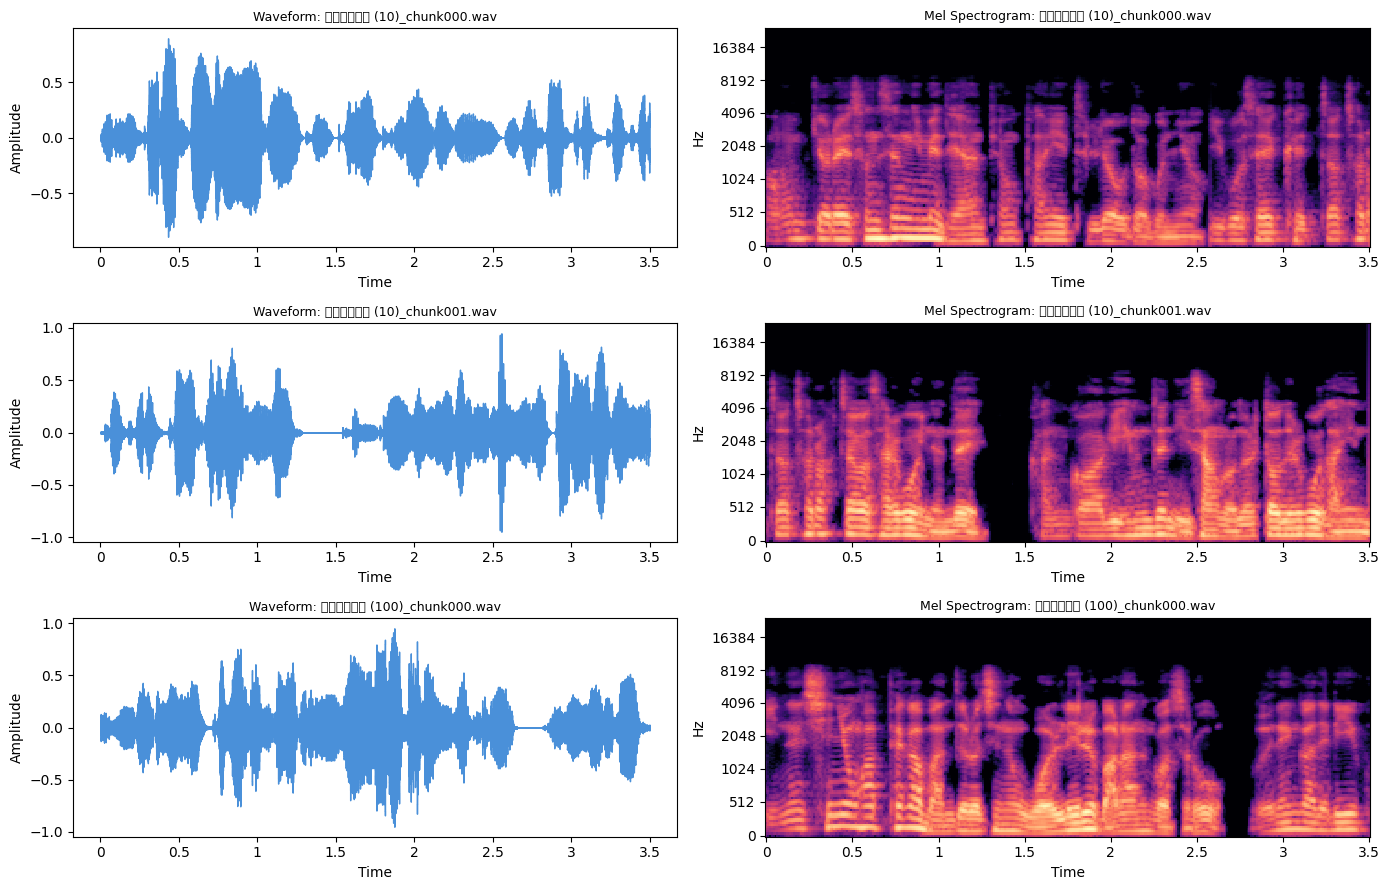


🔊 미리듣기: 녹음 (10)_chunk000.wav


In [ ]:
# =============================================================================
# [셀 7] 전처리 결과 시각화 & 오디오 미리듣기 (선택)
# =============================================================================
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import soundfile as sf

FEAT_WAV_DIR = "/content/drive/MyDrive/RVC_MetaLearning/features/wav"

# 청크 파일 목록
chunk_files = sorted([
    f for f in os.listdir(FEAT_WAV_DIR) if f.endswith(".wav")
])
print(f"📊 전처리된 청크 파일: {len(chunk_files)}개\n")

# 처음 3개 청크 시각화
fig, axes = plt.subplots(min(3, len(chunk_files)), 2,
                          figsize=(14, 3 * min(3, len(chunk_files))))
if min(3, len(chunk_files)) == 1:
    axes = axes.reshape(1, -1)

for i in range(min(3, len(chunk_files))):
    filepath = os.path.join(FEAT_WAV_DIR, chunk_files[i])
    audio, sr = sf.read(filepath)

    # 파형
    ax_wave = axes[i, 0]
    librosa.display.waveshow(audio, sr=sr, ax=ax_wave, color='#4A90D9')
    ax_wave.set_title(f"Waveform: {chunk_files[i]}", fontsize=9)
    ax_wave.set_ylabel("Amplitude")

    # 멜 스펙트로그램
    ax_mel = axes[i, 1]
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, ax=ax_mel, x_axis='time',
                              y_axis='mel', cmap='magma')
    ax_mel.set_title(f"Mel Spectrogram: {chunk_files[i]}", fontsize=9)

plt.tight_layout()
plt.show()

# 첫 번째 청크 미리듣기
if chunk_files:
    filepath = os.path.join(FEAT_WAV_DIR, chunk_files[0])
    audio, sr = sf.read(filepath)
    print(f"\n🔊 미리듣기: {chunk_files[0]}")
    display(Audio(audio, rate=sr))


In [ ]:
# =============================================================================
# [셀 8] 특성 추출 - HuBERT 콘텐츠 임베딩 (768-dim)
# =============================================================================
# HuggingFace transformers 사용 (fairseq 대체)
import os, sys
import numpy as np
import torch
import soundfile as sf
from tqdm import tqdm
from transformers import HubertModel, Wav2Vec2FeatureExtractor

# ===== 경로 설정 =====
DRIVE_ROOT   = "/content/drive/MyDrive/RVC_MetaLearning"
FEAT_WAV_DIR = f"{DRIVE_ROOT}/features/wav"
HUBERT_DIR   = f"{DRIVE_ROOT}/features/hubert"
TARGET_SR    = 48000

os.makedirs(HUBERT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== HuBERT 모델 로드 (HuggingFace) =====
print("=" * 60)
print("🧠 Step 3-A: HuBERT 콘텐츠 특성 추출")
print("=" * 60)

HUBERT_MODEL_NAME = "facebook/hubert-base-ls960"

print(f"📦 HuBERT 모델 로드 중... ({HUBERT_MODEL_NAME})")
processor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL_NAME)
hubert_model = HubertModel.from_pretrained(HUBERT_MODEL_NAME).to(device)
hubert_model.eval()
print(f"✅ HuBERT 모델 로드 완료 (device: {device})")


def extract_hubert_features(audio_path, model, processor, device):
    """
    WAV 파일에서 HuBERT 768-dim 콘텐츠 특성 추출

    Returns:
        feats: np.ndarray, shape (T, 768)
    """
    audio, sr = sf.read(audio_path)

    # 16kHz로 리샘플 (HuBERT 입력 요구사항)
    if sr != 16000:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

    # processor로 입력 준비
    inputs = processor(
        audio, sampling_rate=16000,
        return_tensors="pt", padding=True
    )
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = model(input_values, output_hidden_states=True)
        # 12번째 레이어 (마지막 hidden state) 사용 → 768-dim
        feats = outputs.hidden_states[12]  # (1, T, 768)

    return feats.squeeze(0).cpu().numpy()


# ===== 전체 청크에 대해 특성 추출 =====
chunk_files = sorted([f for f in os.listdir(FEAT_WAV_DIR) if f.endswith(".wav")])
print(f"\n📂 처리할 청크: {len(chunk_files)}개\n")

extracted = 0
skipped = 0

for fname in tqdm(chunk_files, desc="HuBERT 추출"):
    wav_path = os.path.join(FEAT_WAV_DIR, fname)
    npy_name = os.path.splitext(fname)[0] + ".npy"
    npy_path = os.path.join(HUBERT_DIR, npy_name)

    # 이미 추출된 경우 스킵
    if os.path.exists(npy_path):
        skipped += 1
        continue

    try:
        feats = extract_hubert_features(wav_path, hubert_model, processor, device)
        np.save(npy_path, feats)
        extracted += 1
    except Exception as e:
        print(f"\n  ⚠️ {fname} 실패: {e}")

print(f"\n{'='*60}")
print(f"✅ HuBERT 특성 추출 완료!")
print(f"  📊 추출: {extracted}개 | 스킵(기존): {skipped}개")
print(f"  📊 특성 차원: 768-dim | 저장: {HUBERT_DIR}")

# 샘플 확인
if os.listdir(HUBERT_DIR):
    sample = np.load(os.path.join(HUBERT_DIR, os.listdir(HUBERT_DIR)[0]))
    print(f"  📊 샘플 shape: {sample.shape}  (T={sample.shape[0]} 프레임)")


🧠 Step 3-A: HuBERT 콘텐츠 특성 추출
📦 HuBERT 모델 로드 중... (facebook/hubert-base-ls960)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

✅ HuBERT 모델 로드 완료 (device: cuda)

📂 처리할 청크: 250개




HuBERT 추출: 100%|██████████| 250/250 [00:11<00:00, 22.23it/s]


✅ HuBERT 특성 추출 완료!
  📊 추출: 250개 | 스킵(기존): 0개
  📊 특성 차원: 768-dim | 저장: /content/drive/MyDrive/RVC_MetaLearning/features/hubert
  📊 샘플 shape: (174, 768)  (T=174 프레임)


In [ ]:
# =============================================================================
# [셀 9] 특성 추출 - RMVPE F0 피치 추출
# =============================================================================
import os, sys
import numpy as np
import torch
import soundfile as sf
from tqdm import tqdm

RVC_DIR = "/content/Retrieval-based-Voice-Conversion-WebUI"
if RVC_DIR not in sys.path:
    sys.path.insert(0, RVC_DIR)

# ===== 경로 설정 =====
DRIVE_ROOT   = "/content/drive/MyDrive/RVC_MetaLearning"
FEAT_WAV_DIR = f"{DRIVE_ROOT}/features/wav"
F0_DIR       = f"{DRIVE_ROOT}/features/f0"
RMVPE_PATH   = f"{DRIVE_ROOT}/pretrained/rmvpe.pt"
TARGET_SR    = 48000
HOP_LENGTH   = 480    # 48000 / 100 = 480 (10ms 프레임)
F0_MIN       = 50     # 최소 F0 (Hz)
F0_MAX       = 1100   # 최대 F0 (Hz)

os.makedirs(F0_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("🎵 Step 3-B: RMVPE F0 피치 추출")
print("=" * 60)

# ===== RMVPE 모델 로드 =====
# RVC 내장 RMVPE 사용 시도, 실패하면 torchcrepe 폴백
try:
    from infer.lib.rmvpe import RMVPE
    print(f"📦 RMVPE 모델 로드 중... ({RMVPE_PATH})")
    rmvpe_model = RMVPE(RMVPE_PATH, is_half=False, device=device)
    USE_RMVPE = True
    print(f"✅ RMVPE 모델 로드 완료")
except Exception as e:
    print(f"⚠️ RMVPE 로드 실패: {e}")
    print("📦 torchcrepe로 대체합니다...")
    import torchcrepe
    USE_RMVPE = False
    print("✅ torchcrepe 로드 완료")


def extract_f0_rmvpe(audio_path):
    """RMVPE로 F0 추출"""
    audio, sr = sf.read(audio_path)
    audio_tensor = torch.from_numpy(audio).float()

    # RMVPE는 16kHz 입력 기대
    if sr != 16000:
        audio_16k = torch.nn.functional.interpolate(
            audio_tensor.unsqueeze(0).unsqueeze(0),
            scale_factor=16000 / sr, mode='linear', align_corners=False
        ).squeeze()
    else:
        audio_16k = audio_tensor

    f0 = rmvpe_model.infer_from_audio(audio_16k.numpy(), thred=0.03)
    return f0


def extract_f0_crepe(audio_path):
    """torchcrepe로 F0 추출 (RMVPE 대체)"""
    audio, sr = sf.read(audio_path)
    audio_tensor = torch.from_numpy(audio).float().unsqueeze(0).to(device)

    if sr != 16000:
        audio_tensor = torch.nn.functional.interpolate(
            audio_tensor.unsqueeze(0), scale_factor=16000 / sr,
            mode='linear', align_corners=False
        ).squeeze(0)
        sr = 16000

    # CREPE로 F0 추출
    f0, periodicity = torchcrepe.predict(
        audio_tensor, sr,
        hop_length=160,  # 16kHz 기준 10ms
        fmin=F0_MIN, fmax=F0_MAX,
        model='full', batch_size=512,
        device=device, return_periodicity=True
    )

    # 낮은 주기성 구간은 0으로 (무성음)
    periodicity = torchcrepe.filter.median(periodicity, 3)
    f0 = torchcrepe.filter.mean(f0, 3)
    f0[periodicity < 0.1] = 0

    return f0.squeeze().cpu().numpy()


def extract_f0(audio_path):
    """F0 추출 (RMVPE 우선, 실패 시 CREPE)"""
    if USE_RMVPE:
        return extract_f0_rmvpe(audio_path)
    else:
        return extract_f0_crepe(audio_path)


# ===== 전체 청크에 대해 F0 추출 =====
chunk_files = sorted([f for f in os.listdir(FEAT_WAV_DIR) if f.endswith(".wav")])
print(f"\n📂 처리할 청크: {len(chunk_files)}개\n")

extracted = 0
skipped = 0

for fname in tqdm(chunk_files, desc="F0 추출"):
    wav_path = os.path.join(FEAT_WAV_DIR, fname)
    npy_name = os.path.splitext(fname)[0] + "_f0.npy"
    npy_path = os.path.join(F0_DIR, npy_name)

    if os.path.exists(npy_path):
        skipped += 1
        continue

    try:
        f0 = extract_f0(wav_path)
        np.save(npy_path, f0)
        extracted += 1
    except Exception as e:
        print(f"\n  ⚠️ {fname} 실패: {e}")

print(f"\n{'='*60}")
print(f"✅ F0 피치 추출 완료!")
print(f"  📊 추출: {extracted}개 | 스킵(기존): {skipped}개")
print(f"  📊 저장: {F0_DIR}")

# 샘플 확인
sample_f0 = np.load(os.path.join(F0_DIR, os.listdir(F0_DIR)[0]))
print(f"  📊 샘플 shape: {sample_f0.shape}")
print(f"  📊 F0 범위: {sample_f0[sample_f0>0].min():.1f} ~ "
      f"{sample_f0[sample_f0>0].max():.1f} Hz")


🎵 Step 3-B: RMVPE F0 피치 추출
📦 RMVPE 모델 로드 중... (/content/drive/MyDrive/RVC_MetaLearning/pretrained/rmvpe.pt)
✅ RMVPE 모델 로드 완료

📂 처리할 청크: 250개



F0 추출: 100%|██████████| 250/250 [00:11<00:00, 21.45it/s]


✅ F0 피치 추출 완료!
  📊 추출: 250개 | 스킵(기존): 0개
  📊 저장: /content/drive/MyDrive/RVC_MetaLearning/features/f0
  📊 샘플 shape: (351,)
  📊 F0 범위: 74.7 ~ 149.5 Hz


/tmp/ipykernel_1663/3430925807.py:62: UserWarning: Glyph 4354 (\N{HANGUL CHOSEONG NIEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/3430925807.py:62: UserWarning: Glyph 4457 (\N{HANGUL JUNGSEONG O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/3430925807.py:62: UserWarning: Glyph 4520 (\N{HANGUL JONGSEONG KIYEOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/3430925807.py:62: UserWarning: Glyph 4363 (\N{HANGUL CHOSEONG IEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/3430925807.py:62: UserWarning: Glyph 4467 (\N{HANGUL JUNGSEONG EU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/3430925807.py:62: UserWarning: Glyph 4535 (\N{HANGUL JONGSEONG MIEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


📊 Step 3 특성 추출 검증
  WAV 청크:   250개
  HuBERT 특성: 250개
  F0 특성:     250개

  ✅ 모든 청크에 대해 특성 추출 완료!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4354 (\N{HANGUL CHOSEONG NIEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4457 (\N{HANGUL JUNGSEONG O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4520 (\N{HANGUL JONGSEONG KIYEOK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4363 (\N{HANGUL CHOSEONG IEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4467 (\N{HANGUL JUNGSEONG EU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

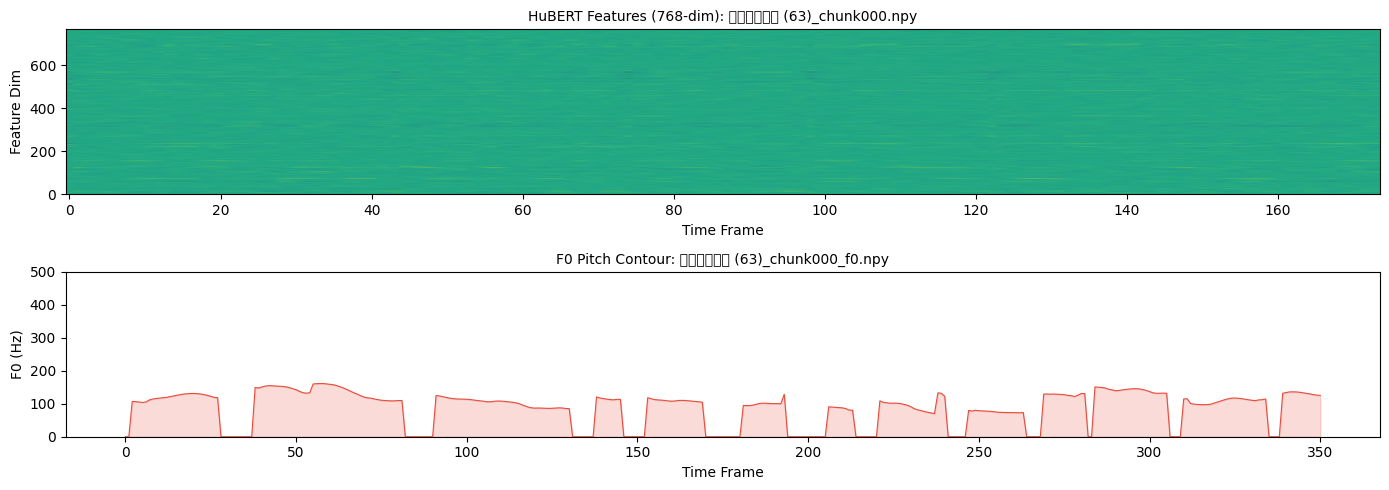


✅ Step 3 완료: 특성 추출

다음 단계: Step 4 (모델 정의 & Reptile 메타러닝)


In [ ]:
# =============================================================================
# [셀 10] 특성 추출 검증 & 요약
# =============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt

DRIVE_ROOT = "/content/drive/MyDrive/RVC_MetaLearning"
HUBERT_DIR = f"{DRIVE_ROOT}/features/hubert"
F0_DIR     = f"{DRIVE_ROOT}/features/f0"
FEAT_WAV_DIR = f"{DRIVE_ROOT}/features/wav"

hubert_files = sorted([f for f in os.listdir(HUBERT_DIR) if f.endswith(".npy")])
f0_files = sorted([f for f in os.listdir(F0_DIR) if f.endswith(".npy")])
wav_files = sorted([f for f in os.listdir(FEAT_WAV_DIR) if f.endswith(".wav")])

print("=" * 60)
print("📊 Step 3 특성 추출 검증")
print("=" * 60)
print(f"  WAV 청크:   {len(wav_files)}개")
print(f"  HuBERT 특성: {len(hubert_files)}개")
print(f"  F0 특성:     {len(f0_files)}개")

# 매칭 확인
wav_names = {os.path.splitext(f)[0] for f in wav_files}
hub_names = {os.path.splitext(f)[0] for f in hubert_files}
f0_names  = {os.path.splitext(f)[0].replace("_f0", "") for f in f0_files}

missing_hub = wav_names - hub_names
missing_f0  = wav_names - f0_names

if missing_hub:
    print(f"\n  ⚠️ HuBERT 누락: {len(missing_hub)}개")
if missing_f0:
    print(f"  ⚠️ F0 누락: {len(missing_f0)}개")
if not missing_hub and not missing_f0:
    print(f"\n  ✅ 모든 청크에 대해 특성 추출 완료!")

# 시각화 - 랜덤 샘플 1개
if hubert_files and f0_files:
    idx = np.random.randint(len(hubert_files))
    hub_feat = np.load(os.path.join(HUBERT_DIR, hubert_files[idx]))
    f0_name = os.path.splitext(hubert_files[idx])[0] + "_f0.npy"
    f0_feat = np.load(os.path.join(F0_DIR, f0_name))

    fig, axes = plt.subplots(2, 1, figsize=(14, 5))

    # HuBERT 히트맵
    axes[0].imshow(hub_feat.T, aspect='auto', origin='lower', cmap='viridis')
    axes[0].set_title(f"HuBERT Features (768-dim): {hubert_files[idx]}", fontsize=10)
    axes[0].set_ylabel("Feature Dim")
    axes[0].set_xlabel("Time Frame")

    # F0 곡선
    axes[1].plot(f0_feat, color='#E74C3C', linewidth=0.8)
    axes[1].fill_between(range(len(f0_feat)), f0_feat, alpha=0.2, color='#E74C3C')
    axes[1].set_title(f"F0 Pitch Contour: {f0_name}", fontsize=10)
    axes[1].set_ylabel("F0 (Hz)")
    axes[1].set_xlabel("Time Frame")
    axes[1].set_ylim(0, max(f0_feat.max() * 1.1, 500))

    plt.tight_layout()
    plt.show()

print(f"\n{'='*60}")
print(f"✅ Step 3 완료: 특성 추출")
print(f"{'='*60}")
print(f"\n다음 단계: Step 4 (모델 정의 & Reptile 메타러닝)")


In [ ]:
# =============================================================================
# [셀 11] 데이터셋 & 데이터로더 정의
# =============================================================================
import os, sys
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
import librosa
import random

RVC_DIR = "/content/Retrieval-based-Voice-Conversion-WebUI"
if RVC_DIR not in sys.path:
    sys.path.insert(0, RVC_DIR)

DRIVE_ROOT   = "/content/drive/MyDrive/RVC_MetaLearning"
FEAT_WAV_DIR = f"{DRIVE_ROOT}/features/wav"
HUBERT_DIR   = f"{DRIVE_ROOT}/features/hubert"
F0_DIR       = f"{DRIVE_ROOT}/features/f0"

TARGET_SR    = 48000
HOP_LENGTH   = 480
SEGMENT_SIZE = 12000   # 학습 세그먼트 크기 (샘플 수, 48kHz 기준 0.25초)
N_FFT        = 2048
WIN_LENGTH   = 2048


class RVCDataset(Dataset):
    """
    RVC 학습용 데이터셋
    - WAV 오디오
    - HuBERT 768-dim 특성
    - F0 피치 정보
    - 스펙트로그램 (on-the-fly 생성)
    """

    def __init__(self, wav_dir, hubert_dir, f0_dir,
                 sr=TARGET_SR, segment_size=SEGMENT_SIZE,
                 hop_length=HOP_LENGTH, n_fft=N_FFT,
                 win_length=WIN_LENGTH, file_list=None):
        self.sr = sr
        self.segment_size = segment_size
        self.hop_length = hop_length
        self.n_fft = n_fft
        self.win_length = win_length

        # 유효한 샘플만 (WAV + HuBERT + F0 모두 존재)
        all_wavs = sorted([f for f in os.listdir(wav_dir) if f.endswith(".wav")])
        if file_list is not None:
            all_wavs = [f for f in all_wavs if f in file_list]

        self.samples = []
        for wav_name in all_wavs:
            base = os.path.splitext(wav_name)[0]
            hub_path = os.path.join(hubert_dir, base + ".npy")
            f0_path = os.path.join(f0_dir, base + "_f0.npy")
            wav_path = os.path.join(wav_dir, wav_name)
            if os.path.exists(hub_path) and os.path.exists(f0_path):
                self.samples.append((wav_path, hub_path, f0_path))

        # Hann 윈도우 (스펙트로그램용)
        self.hann_window = torch.hann_window(win_length)

    def __len__(self):
        return len(self.samples)

    def _compute_spec(self, audio_tensor):
        """리니어 스펙트로그램 계산"""
        # (1, T) -> STFT
        audio_padded = F.pad(
            audio_tensor.unsqueeze(0),
            (int((self.n_fft - self.hop_length) / 2),
             int((self.n_fft - self.hop_length) / 2)),
            mode='reflect'
        )
        spec = torch.stft(
            audio_padded.squeeze(0), self.n_fft,
            hop_length=self.hop_length, win_length=self.win_length,
            window=self.hann_window, center=False,
            return_complex=True
        )
        spec = torch.abs(spec) + 1e-6  # magnitude
        spec = torch.log(spec)
        return spec  # (n_fft//2+1, T_spec)

    def __getitem__(self, idx):
        wav_path, hub_path, f0_path = self.samples[idx]

        # 1. 오디오 로드
        audio, _ = sf.read(wav_path)
        audio = torch.from_numpy(audio).float()

        # 2. HuBERT 특성 로드
        hubert = torch.from_numpy(np.load(hub_path)).float()  # (T_h, 768)

        # 3. F0 로드
        f0 = torch.from_numpy(np.load(f0_path)).float()  # (T_f,)

        # 4. 랜덤 세그먼트 선택
        if audio.shape[0] >= self.segment_size:
            max_start = audio.shape[0] - self.segment_size
            start = random.randint(0, max_start)
            audio = audio[start:start + self.segment_size]

            # 대응하는 프레임 범위 계산
            frame_start = start // self.hop_length
            n_frames = self.segment_size // self.hop_length
        else:
            # 짧은 경우 패딩
            audio = F.pad(audio, (0, self.segment_size - audio.shape[0]))
            frame_start = 0
            n_frames = self.segment_size // self.hop_length

        # 5. HuBERT & F0를 프레임 범위에 맞게 슬라이스
        hub_end = min(frame_start + n_frames, hubert.shape[0])
        hubert_seg = hubert[frame_start:hub_end]  # (n_frames, 768)

        f0_end = min(frame_start + n_frames, f0.shape[0])
        f0_seg = f0[frame_start:f0_end]  # (n_frames,)

        # 길이 맞추기
        if hubert_seg.shape[0] < n_frames:
            pad_len = n_frames - hubert_seg.shape[0]
            hubert_seg = F.pad(hubert_seg, (0, 0, 0, pad_len))
        if f0_seg.shape[0] < n_frames:
            pad_len = n_frames - f0_seg.shape[0]
            f0_seg = F.pad(f0_seg, (0, pad_len))

        # 6. 스펙트로그램 계산
        spec = self._compute_spec(audio)  # (1025, T_spec)
        spec = spec[:, :n_frames]
        if spec.shape[1] < n_frames:
            spec = F.pad(spec, (0, n_frames - spec.shape[1]))

        # 7. f0를 coarse 인덱스로 변환 (RVC 방식)
        f0_coarse = torch.zeros_like(f0_seg, dtype=torch.long)
        f0_voiced = f0_seg > 0
        if f0_voiced.any():
            f0_mel = 1127 * torch.log(1 + f0_seg[f0_voiced] / 700)
            f0_mel_min = 1127 * np.log(1 + 50 / 700)
            f0_mel_max = 1127 * np.log(1 + 1100 / 700)
            f0_norm = (f0_mel - f0_mel_min) / (f0_mel_max - f0_mel_min)
            f0_coarse[f0_voiced] = (f0_norm * 255).clamp(1, 255).long()

        # hubert_seg: (T, 768) → (768, T) for conv1d in model
        hubert_seg = hubert_seg.transpose(0, 1)

        return {
            'audio': audio,                  # (segment_size,)
            'spec': spec,                    # (1025, n_frames)
            'hubert': hubert_seg,            # (768, n_frames)
            'f0': f0_seg,                    # (n_frames,)
            'f0_coarse': f0_coarse,          # (n_frames,)
            'lengths': torch.tensor(n_frames, dtype=torch.long),
        }


def collate_fn(batch):
    """배치 collate (동일 길이 보장)"""
    keys = batch[0].keys()
    result = {}
    for key in keys:
        if key == 'lengths':
            result[key] = torch.stack([b[key] for b in batch])
        elif batch[0][key].dim() == 0:
            result[key] = torch.stack([b[key] for b in batch])
        else:
            result[key] = torch.stack([b[key] for b in batch])
    return result


# ===== 데이터셋 생성 & 검증 =====
print("=" * 60)
print("📦 Step 4-A: 데이터셋 구성")
print("=" * 60)

dataset = RVCDataset(FEAT_WAV_DIR, HUBERT_DIR, F0_DIR)
print(f"✅ 데이터셋: {len(dataset)}개 샘플")

# 샘플 1개 로드 테스트
sample = dataset[0]
print(f"\n📊 샘플 shape 확인:")
for key, val in sample.items():
    print(f"  {key:12s}: {val.shape}")

print(f"\n✅ 데이터셋 준비 완료!")


📦 Step 4-A: 데이터셋 구성
✅ 데이터셋: 250개 샘플

📊 샘플 shape 확인:
  audio       : torch.Size([12000])
  spec        : torch.Size([1025, 25])
  hubert      : torch.Size([768, 25])
  f0          : torch.Size([25])
  f0_coarse   : torch.Size([25])
  lengths     : torch.Size([])

✅ 데이터셋 준비 완료!


In [ ]:
# =============================================================================
# [셀 12] 모델 로드 & 손실 함수 정의
# =============================================================================
import os, sys, copy
import torch
import torch.nn as nn
import torch.nn.functional as F

RVC_DIR = "/content/Retrieval-based-Voice-Conversion-WebUI"
if RVC_DIR not in sys.path:
    sys.path.insert(0, RVC_DIR)

DRIVE_ROOT     = "/content/drive/MyDrive/RVC_MetaLearning"
PRETRAINED_G   = f"{DRIVE_ROOT}/pretrained/f0G48k.pth"
PRETRAINED_D   = f"{DRIVE_ROOT}/pretrained/f0D48k.pth"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"

device = torch.device("cuda")

print("=" * 60)
print("🏗️ Step 4-B: 모델 로드 & 손실 함수")
print("=" * 60)

# ===== RVC v2 모델 클래스 임포트 =====
from infer.lib.infer_pack.models import (
    SynthesizerTrnMs768NSFsid as Generator,
    MultiPeriodDiscriminator as Discriminator,
)

# ===== Generator 초기화 & 사전학습 가중치 로드 =====
print("\n📦 Generator 초기화...")
net_g = Generator(
    spec_channels=1025,
    segment_size=12000 // 480,  # segment_size in frames
    inter_channels=192,
    hidden_channels=192,
    filter_channels=768,
    n_heads=2,
    n_layers=6,
    kernel_size=3,
    p_dropout=0,
    resblock="1",
    resblock_kernel_sizes=[3, 7, 11],
    resblock_dilation_sizes=[[1, 3, 5], [1, 3, 5], [1, 3, 5]],
    upsample_rates=[12, 10, 2, 2],
    upsample_initial_channel=512,
    upsample_kernel_sizes=[24, 20, 4, 4],
    spk_embed_dim=109,
    gin_channels=256,
    sr=48000,
    is_half=False,
).to(device)

# 사전학습 가중치 로드
print(f"📥 Generator 사전학습 가중치 로드: {PRETRAINED_G}")
pretrained_g = torch.load(PRETRAINED_G, map_location=device, weights_only=False)
# RVC 사전학습 모델은 'model' 키에 state_dict 저장
if 'model' in pretrained_g:
    state_dict_g = pretrained_g['model']
else:
    state_dict_g = pretrained_g

# strict=False: 누락/불일치 키 허용
missing_g, unexpected_g = net_g.load_state_dict(state_dict_g, strict=False)
print(f"  ✅ 로드 완료 (누락: {len(missing_g)}, 미사용: {len(unexpected_g)})")

# ===== Discriminator 초기화 & 사전학습 가중치 로드 =====
print(f"\n📦 Discriminator 초기화...")
net_d = Discriminator(
    use_spectral_norm=False,
).to(device)

print(f"📥 Discriminator 사전학습 가중치 로드: {PRETRAINED_D}")
pretrained_d = torch.load(PRETRAINED_D, map_location=device, weights_only=False)
if 'model' in pretrained_d:
    state_dict_d = pretrained_d['model']
else:
    state_dict_d = pretrained_d

missing_d, unexpected_d = net_d.load_state_dict(state_dict_d, strict=False)
print(f"  ✅ 로드 완료 (누락: {len(missing_d)}, 미사용: {len(unexpected_d)})")

# ===== 파라미터 수 =====
g_params = sum(p.numel() for p in net_g.parameters()) / 1e6
d_params = sum(p.numel() for p in net_d.parameters()) / 1e6
print(f"\n📊 Generator 파라미터:     {g_params:.2f}M")
print(f"📊 Discriminator 파라미터: {d_params:.2f}M")


# ===== 손실 함수 정의 =====
def generator_loss(disc_outputs):
    """Generator adversarial loss (hinge)"""
    loss = 0
    for dg in disc_outputs:
        dg = dg.float()
        loss += torch.mean((1 - dg) ** 2)
    return loss


def discriminator_loss(disc_real_outputs, disc_generated_outputs):
    """Discriminator loss (hinge)"""
    loss = 0
    for dr, dg in zip(disc_real_outputs, disc_generated_outputs):
        dr, dg = dr.float(), dg.float()
        r_loss = torch.mean((1 - dr) ** 2)
        g_loss = torch.mean(dg ** 2)
        loss += (r_loss + g_loss)
    return loss


def feature_matching_loss(fmap_r, fmap_g):
    """Feature matching loss between real/generated feature maps"""
    loss = 0
    for dr, dg in zip(fmap_r, fmap_g):
        for rl, gl in zip(dr, dg):
            rl, gl = rl.float().detach(), gl.float()
            loss += torch.mean(torch.abs(rl - gl))
    return loss * 2


def kl_loss(z_p, logs_q, m_p, logs_p, z_mask):
    """KL divergence loss"""
    z_p = z_p.float()
    logs_q = logs_q.float()
    m_p = m_p.float()
    logs_p = logs_p.float()
    z_mask = z_mask.float()

    kl = logs_p - logs_q - 0.5
    kl += 0.5 * ((z_p - m_p) ** 2) * torch.exp(-2.0 * logs_p)
    kl = torch.sum(kl * z_mask)
    loss = kl / torch.sum(z_mask)
    return loss


def mel_spectrogram_loss(y, y_hat, n_fft=1024, hop_length=240,
                          win_length=1024, n_mels=80, sr=48000):
    """Mel spectrogram reconstruction loss"""
    mel_basis = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels)
    mel_basis = torch.from_numpy(mel_basis).float().to(y.device)

    def _mel(x):
        x = x.squeeze(1) if x.dim() == 3 else x
        window = torch.hann_window(win_length).to(x.device)
        pad = (n_fft - hop_length) // 2
        x = F.pad(x, (pad, pad), mode='reflect')
        spec = torch.stft(x, n_fft, hop_length, win_length,
                          window=window, center=False, return_complex=True)
        spec = torch.abs(spec)
        mel = torch.matmul(mel_basis, spec)
        mel = torch.log(torch.clamp(mel, min=1e-5))
        return mel

    return F.l1_loss(_mel(y), _mel(y_hat))


import librosa  # mel_spectrogram_loss에서 필요

print(f"\n✅ 손실 함수 정의 완료")
print(f"  - generator_loss (adversarial)")
print(f"  - discriminator_loss (hinge)")
print(f"  - feature_matching_loss")
print(f"  - kl_loss (VAE)")
print(f"  - mel_spectrogram_loss (reconstruction)")


🏗️ Step 4-B: 모델 로드 & 손실 함수

📦 Generator 초기화...


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


📥 Generator 사전학습 가중치 로드: /content/drive/MyDrive/RVC_MetaLearning/pretrained/f0G48k.pth
  ✅ 로드 완료 (누락: 0, 미사용: 0)

📦 Discriminator 초기화...
📥 Discriminator 사전학습 가중치 로드: /content/drive/MyDrive/RVC_MetaLearning/pretrained/f0D48k.pth
  ✅ 로드 완료 (누락: 0, 미사용: 36)

📊 Generator 파라미터:     37.64M
📊 Discriminator 파라미터: 54.97M

✅ 손실 함수 정의 완료
  - generator_loss (adversarial)
  - discriminator_loss (hinge)
  - feature_matching_loss
  - kl_loss (VAE)
  - mel_spectrogram_loss (reconstruction)



🧬 Reptile 메타러닝 시작
  메타 스텝:     80
  Inner 스텝:    8
  Meta LR (β):   0.3
  Inner LR:      0.0001
  태스크 샘플:   20
  태스크 배치:   6

  [  1/80] loss_g: 1472.1623 | β: 0.2963 | elapsed: 0.2min | ETA: 18.4min
  [  5/80] loss_g: 208.7012 | β: 0.2812 | elapsed: 0.7min | ETA: 10.4min
  [ 10/80] loss_g: 151.9593 | β: 0.2625 | elapsed: 1.3min | ETA: 8.9min
  [ 15/80] loss_g: 140.5343 | β: 0.2437 | elapsed: 1.9min | ETA: 8.0min
  [ 20/80] loss_g: 122.1136 | β: 0.2250 | elapsed: 2.5min | ETA: 7.4min
  💾 체크포인트 저장: meta_step0020_G/D.pth
  [ 25/80] loss_g: 132.8683 | β: 0.2062 | elapsed: 3.1min | ETA: 6.8min
  [ 30/80] loss_g: 107.0691 | β: 0.1875 | elapsed: 3.7min | ETA: 6.2min
  [ 35/80] loss_g: 109.9995 | β: 0.1687 | elapsed: 4.3min | ETA: 5.6min
  [ 40/80] loss_g: 95.8268 | β: 0.1500 | elapsed: 4.9min | ETA: 4.9min
  💾 체크포인트 저장: meta_step0040_G/D.pth
  [ 45/80] loss_g: 103.2198 | β: 0.1313 | elapsed: 5.6min | ETA: 4.4min
  [ 50/80] loss_g: 119.4176 | β: 0.1125 | elapsed: 6.2min | ETA: 3.7min
  [ 55/

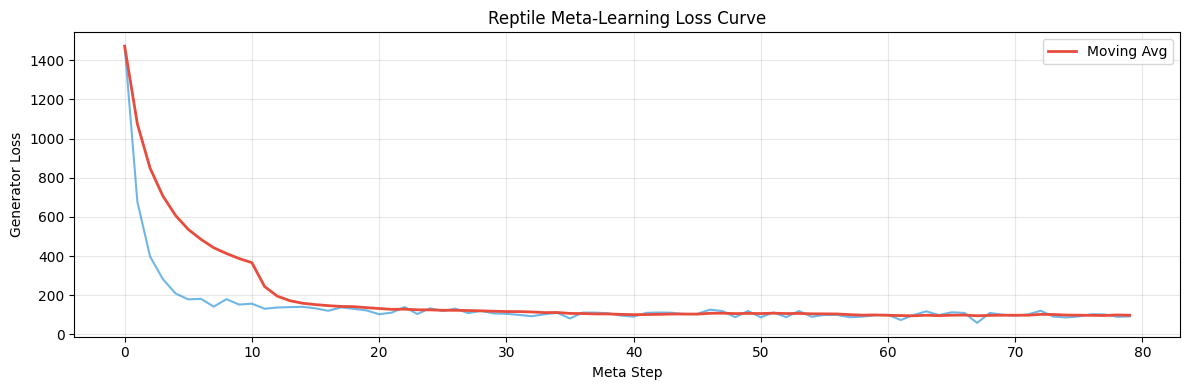

In [ ]:
# =============================================================================
# [셀 13] Reptile 메타러닝 학습
# =============================================================================
#
# Reptile 알고리즘:
#   1. θ = 현재 메타 파라미터 (사전학습 가중치로 초기화)
#   2. 각 메타 스텝마다:
#      a) 타겟 데이터의 랜덤 서브셋으로 "태스크" 구성
#      b) Inner loop: 태스크 데이터에서 k번 SGD → 적응된 가중치 W
#      c) Outer loop: θ ← θ + β(W - θ)
#   3. 결과: 타겟 화자에 빠르게 적응 가능한 초기화 지점
#
import os, copy, random, time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

# ===== Reptile 하이퍼파라미터 =====
NUM_META_STEPS  = 80     # 메타 학습 스텝 수
INNER_STEPS     = 8      # Inner loop 스텝 수
META_LR         = 0.3    # Outer loop 학습률 (β)
INNER_LR        = 1e-4   # Inner loop 학습률
TASK_BATCH_SIZE = 6      # 태스크당 배치 크기
NUM_TASK_SAMPLES = 20    # 태스크당 샘플 수 (데이터셋에서 랜덤 추출)
SPEAKER_ID      = 0      # 타겟 화자 ID (단일 화자이므로 0)

CHECKPOINT_DIR = "/content/drive/MyDrive/RVC_MetaLearning/checkpoints"
device = torch.device("cuda")


class ReptileTrainer:
    """
    Reptile 메타러닝 트레이너

    단일 화자 시나리오에서 데이터의 서브셋을 다른 "태스크"로 취급하여,
    다양한 음소/억양 패턴에 고르게 적응하는 초기화 지점을 학습합니다.
    이는 과적합 방지 및 일반화 성능 향상에 효과적입니다.
    """

    def __init__(self, net_g, net_d, dataset, device,
                 inner_lr=INNER_LR, meta_lr=META_LR,
                 inner_steps=INNER_STEPS, task_batch_size=TASK_BATCH_SIZE,
                 num_task_samples=NUM_TASK_SAMPLES):
        self.net_g = net_g
        self.net_d = net_d
        self.dataset = dataset
        self.device = device
        self.inner_lr = inner_lr
        self.meta_lr = meta_lr
        self.inner_steps = inner_steps
        self.task_batch_size = task_batch_size
        self.num_task_samples = min(num_task_samples, len(dataset))

    def _sample_task_loader(self):
        """랜덤 서브셋으로 태스크 데이터로더 생성"""
        indices = random.sample(range(len(self.dataset)), self.num_task_samples)
        subset = Subset(self.dataset, indices)
        return DataLoader(
            subset, batch_size=self.task_batch_size,
            shuffle=True, drop_last=True,
            collate_fn=collate_fn, num_workers=0
        )

    def _inner_loop(self, task_loader):
        """
        Inner loop: 태스크 데이터에서 k번 SGD 수행

        Returns:
            avg_loss: 평균 Generator 손실
        """
        self.net_g.train()
        self.net_d.train()

        optim_g = torch.optim.AdamW(
            self.net_g.parameters(), lr=self.inner_lr,
            betas=(0.8, 0.99), weight_decay=0.01
        )
        optim_d = torch.optim.AdamW(
            self.net_d.parameters(), lr=self.inner_lr,
            betas=(0.8, 0.99), weight_decay=0.01
        )

        total_loss_g = 0.0
        steps_done = 0
        data_iter = iter(task_loader)

        for step in range(self.inner_steps):
            try:
                batch = next(data_iter)
            except StopIteration:
                data_iter = iter(task_loader)
                batch = next(data_iter)

            # 데이터를 GPU로
            hubert = batch['hubert'].to(self.device)       # (B, 768, T)
            hubert = hubert.transpose(1, 2)                # → (B, T, 768) for nn.Linear
            spec = batch['spec'].to(self.device)           # (B, 1025, T)
            audio = batch['audio'].to(self.device)         # (B, seg_size)
            f0 = batch['f0'].to(self.device)               # (B, T)
            f0_coarse = batch['f0_coarse'].to(self.device) # (B, T)
            lengths = batch['lengths'].to(self.device)     # (B,)

            audio = audio.unsqueeze(1)  # (B, 1, seg_size)

            # 화자 ID 임베딩
            sid = torch.zeros(hubert.shape[0], dtype=torch.long,
                              device=self.device)

            # ----- Generator Forward -----
            # RVC forward(phone, phone_lengths, pitch, pitchf, y, y_lengths, ds)
            #   pitch=f0_coarse(정수), pitchf=f0(실수), y=spec, y_lengths 필요
            (y_hat, ids_slice, x_mask, z_mask,
             (z, z_p, m_p, logs_p, m_q, logs_q)) = self.net_g(
                hubert, lengths, f0_coarse, f0, spec, lengths, sid
            )

            # 오디오 슬라이스 (Generator 출력에 맞춤)
            y_slice = self._slice_audio(audio, ids_slice)

            # ----- Discriminator 학습 -----
            y_d_hat_r, y_d_hat_g, _, _ = self.net_d(y_slice, y_hat.detach())
            loss_d = discriminator_loss(y_d_hat_r, y_d_hat_g)

            optim_d.zero_grad()
            loss_d.backward()
            torch.nn.utils.clip_grad_norm_(self.net_d.parameters(), max_norm=1.0)
            optim_d.step()

            # ----- Generator 학습 -----
            y_d_hat_r, y_d_hat_g, fmap_r, fmap_g = self.net_d(y_slice, y_hat)

            loss_gen = generator_loss(y_d_hat_g)
            loss_fm = feature_matching_loss(fmap_r, fmap_g)
            loss_kl = kl_loss(z_p, logs_q, m_p, logs_p, z_mask)
            loss_mel = mel_spectrogram_loss(y_slice, y_hat)

            loss_g_total = loss_gen + loss_fm + 40 * loss_kl + 45 * loss_mel

            optim_g.zero_grad()
            loss_g_total.backward()
            torch.nn.utils.clip_grad_norm_(self.net_g.parameters(), max_norm=1.0)
            optim_g.step()

            total_loss_g += loss_g_total.item()
            steps_done += 1

        return total_loss_g / max(steps_done, 1)

    def _slice_audio(self, audio, ids_slice):
        """Generator의 ids_slice에 맞춰 오디오 슬라이스"""
        # ids_slice: (B, 1) — 각 배치의 시작 인덱스
        # audio: (B, 1, T)
        seg_size = self.net_g.segment_size * self.net_g.config.hop_length \
            if hasattr(self.net_g, 'config') else 12000

        # RVC Generator가 반환하는 y_hat 크기에 맞춤
        y_hat_len = ids_slice.shape[-1] if ids_slice.dim() > 1 else 12000
        results = []
        for i in range(audio.shape[0]):
            start = ids_slice[i].item() if ids_slice.dim() == 1 else \
                    ids_slice[i, 0].item()
            start_sample = start * 480  # frame → sample
            end_sample = start_sample + 12000
            if end_sample > audio.shape[2]:
                end_sample = audio.shape[2]
                start_sample = max(0, end_sample - 12000)
            results.append(audio[i:i+1, :, start_sample:end_sample])

        result = torch.cat(results, dim=0)
        # y_hat 크기와 맞추기
        return result

    def train(self, num_meta_steps=NUM_META_STEPS, save_every=20):
        """
        Reptile 메타러닝 메인 루프

        각 스텝에서:
        1. 메타 파라미터 θ 저장
        2. Inner loop로 적응된 가중치 W 획득
        3. θ ← θ + β(W - θ)
        """
        print(f"\n{'='*60}")
        print(f"🧬 Reptile 메타러닝 시작")
        print(f"{'='*60}")
        print(f"  메타 스텝:     {num_meta_steps}")
        print(f"  Inner 스텝:    {self.inner_steps}")
        print(f"  Meta LR (β):   {self.meta_lr}")
        print(f"  Inner LR:      {self.inner_lr}")
        print(f"  태스크 샘플:   {self.num_task_samples}")
        print(f"  태스크 배치:   {self.task_batch_size}")
        print()

        meta_losses = []
        start_time = time.time()

        for meta_step in range(1, num_meta_steps + 1):
            # 1. 현재 메타 파라미터 저장 (θ)
            meta_params_g = {
                name: param.clone()
                for name, param in self.net_g.named_parameters()
            }
            meta_params_d = {
                name: param.clone()
                for name, param in self.net_d.named_parameters()
            }

            # 2. Inner loop: 랜덤 태스크에서 학습 → 적응된 가중치 W
            task_loader = self._sample_task_loader()
            avg_loss = self._inner_loop(task_loader)
            meta_losses.append(avg_loss)

            # 3. Outer loop (Reptile 업데이트): θ ← θ + β(W - θ)
            # β를 스케줄링 (점차 감소)
            progress = meta_step / num_meta_steps
            beta = self.meta_lr * (1.0 - progress)  # linear decay

            with torch.no_grad():
                for name, param in self.net_g.named_parameters():
                    if name in meta_params_g:
                        phi = meta_params_g[name]
                        param.data = phi + beta * (param.data - phi)

                for name, param in self.net_d.named_parameters():
                    if name in meta_params_d:
                        phi = meta_params_d[name]
                        param.data = phi + beta * (param.data - phi)

            # 로깅
            elapsed = time.time() - start_time
            eta = elapsed / meta_step * (num_meta_steps - meta_step)

            if meta_step % 5 == 0 or meta_step == 1:
                print(
                    f"  [{meta_step:3d}/{num_meta_steps}] "
                    f"loss_g: {avg_loss:.4f} | "
                    f"β: {beta:.4f} | "
                    f"elapsed: {elapsed/60:.1f}min | "
                    f"ETA: {eta/60:.1f}min"
                )

            # 체크포인트 저장
            if meta_step % save_every == 0:
                self._save_checkpoint(meta_step, avg_loss)

        # 최종 체크포인트 저장
        self._save_checkpoint(num_meta_steps, meta_losses[-1], final=True)

        total_time = time.time() - start_time
        print(f"\n{'='*60}")
        print(f"✅ Reptile 메타러닝 완료! ({total_time/60:.1f}분)")
        print(f"  최종 loss: {meta_losses[-1]:.4f}")
        print(f"  최소 loss: {min(meta_losses):.4f} "
              f"(step {meta_losses.index(min(meta_losses))+1})")
        print(f"{'='*60}")

        return meta_losses

    def _save_checkpoint(self, step, loss, final=False):
        prefix = "meta_final" if final else f"meta_step{step:04d}"
        g_path = os.path.join(CHECKPOINT_DIR, f"{prefix}_G.pth")
        d_path = os.path.join(CHECKPOINT_DIR, f"{prefix}_D.pth")

        torch.save({
            'model': self.net_g.state_dict(),
            'step': step,
            'loss': loss,
        }, g_path)
        torch.save({
            'model': self.net_d.state_dict(),
            'step': step,
            'loss': loss,
        }, d_path)
        print(f"  💾 체크포인트 저장: {prefix}_G/D.pth")


# ===== Reptile 학습 실행 =====
trainer = ReptileTrainer(
    net_g=net_g,
    net_d=net_d,
    dataset=dataset,
    device=device,
    inner_lr=INNER_LR,
    meta_lr=META_LR,
    inner_steps=INNER_STEPS,
    task_batch_size=TASK_BATCH_SIZE,
    num_task_samples=NUM_TASK_SAMPLES,
)

meta_losses = trainer.train(
    num_meta_steps=NUM_META_STEPS,
    save_every=20,
)

# ===== 메타러닝 손실 시각화 =====
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(meta_losses, color='#3498DB', linewidth=1.5, alpha=0.7)
# 이동 평균
if len(meta_losses) > 5:
    window = min(10, len(meta_losses) // 3)
    ma = [sum(meta_losses[max(0,i-window):i+1])/min(i+1,window+1)
          for i in range(len(meta_losses))]
    plt.plot(ma, color='#E74C3C', linewidth=2, label='Moving Avg')
plt.xlabel('Meta Step')
plt.ylabel('Generator Loss')
plt.title('Reptile Meta-Learning Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


🎯 Step 4-C: Fine-tuning (메타 초기화 기반)
✅ Generator 메타 체크포인트 로드 (step 80)
✅ Discriminator 메타 체크포인트 로드

  에폭:          200
  배치 크기:     8
  LR (G/D):      0.0001
  스케줄러:      CosineAnnealing
  배치 수/에폭:  31

🚀 Fine-tuning 시작...

  [Epoch   1/200] G: 85.8180 | D: 2.3165 | Mel: 0.9940 | LR: 1.00e-04 | ETA: 107.1min
  [Epoch  10/200] G: 61.8945 | D: 2.2778 | Mel: 0.8940 | LR: 9.94e-05 | ETA: 103.5min
  [Epoch  20/200] G: 61.5320 | D: 2.2356 | Mel: 0.9302 | LR: 9.76e-05 | ETA: 97.0min
  💾 체크포인트 저장: ft_epoch0025
  [Epoch  30/200] G: 56.9484 | D: 2.3237 | Mel: 0.8674 | LR: 9.46e-05 | ETA: 91.6min
  [Epoch  40/200] G: 68.2803 | D: 2.0430 | Mel: 0.8709 | LR: 9.05e-05 | ETA: 85.7min
  [Epoch  50/200] G: 69.8981 | D: 1.8542 | Mel: 0.8595 | LR: 8.55e-05 | ETA: 80.2min
  💾 체크포인트 저장: ft_epoch0050
  [Epoch  60/200] G: 63.5740 | D: 2.0690 | Mel: 0.8688 | LR: 7.96e-05 | ETA: 74.9min
  [Epoch  70/200] G: 60.5732 | D: 2.2045 | Mel: 0.8826 | LR: 7.30e-05 | ETA: 69.4min
  💾 체크포인트 저장: ft_epoch0075
  [Epoch  80/2

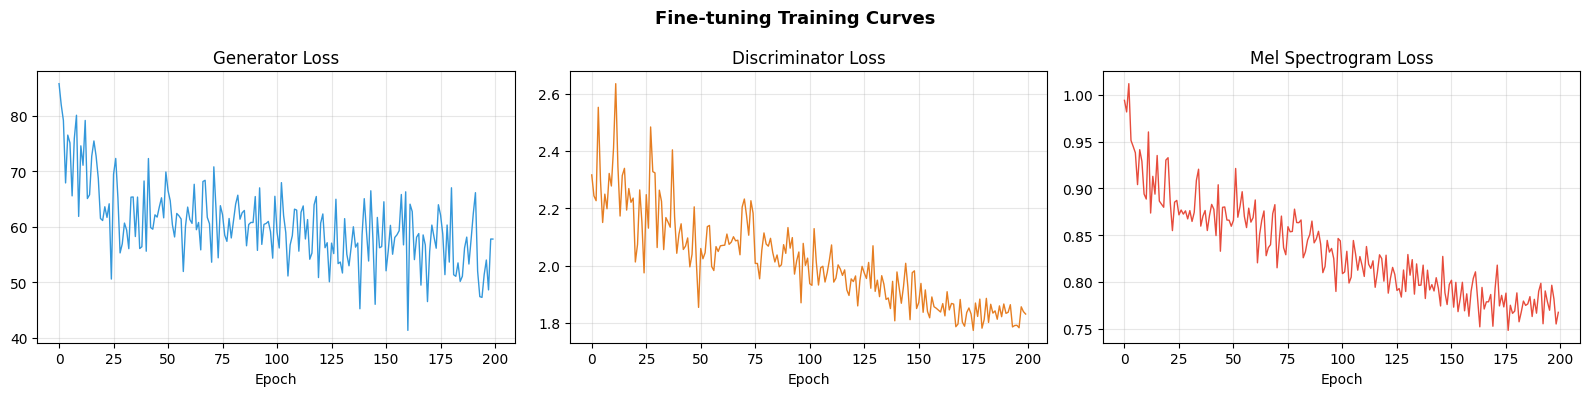

In [ ]:
# =============================================================================
# [셀 14] Fine-tuning (메타 초기화 → 표준 RVC 학습)
# =============================================================================
#
# Reptile로 최적화된 초기화 지점에서 시작하여,
# 전체 타겟 데이터셋으로 표준 학습을 수행합니다.
#
import os, time
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

DRIVE_ROOT     = "/content/drive/MyDrive/RVC_MetaLearning"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints"
MODEL_DIR      = f"{DRIVE_ROOT}/models"
device = torch.device("cuda")

# ===== Fine-tuning 하이퍼파라미터 =====
FT_EPOCHS     = 200
FT_LR_G       = 1e-4
FT_LR_D       = 1e-4
FT_BATCH_SIZE = 8
SAVE_EVERY    = 25
LOG_EVERY     = 10

print("=" * 60)
print("🎯 Step 4-C: Fine-tuning (메타 초기화 기반)")
print("=" * 60)

# ===== 메타러닝 체크포인트에서 로드 (선택) =====
meta_g_path = os.path.join(CHECKPOINT_DIR, "meta_final_G.pth")
meta_d_path = os.path.join(CHECKPOINT_DIR, "meta_final_D.pth")

if os.path.exists(meta_g_path):
    ckpt = torch.load(meta_g_path, map_location=device, weights_only=False)
    net_g.load_state_dict(ckpt['model'])
    print(f"✅ Generator 메타 체크포인트 로드 (step {ckpt['step']})")

if os.path.exists(meta_d_path):
    ckpt = torch.load(meta_d_path, map_location=device, weights_only=False)
    net_d.load_state_dict(ckpt['model'])
    print(f"✅ Discriminator 메타 체크포인트 로드")

# ===== 옵티마이저 & 스케줄러 =====
optim_g = torch.optim.AdamW(
    net_g.parameters(), lr=FT_LR_G,
    betas=(0.8, 0.99), weight_decay=0.01
)
optim_d = torch.optim.AdamW(
    net_d.parameters(), lr=FT_LR_D,
    betas=(0.8, 0.99), weight_decay=0.01
)

scheduler_g = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_g, T_max=FT_EPOCHS, eta_min=1e-6
)
scheduler_d = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_d, T_max=FT_EPOCHS, eta_min=1e-6
)

# ===== 전체 데이터로더 =====
train_loader = DataLoader(
    dataset, batch_size=FT_BATCH_SIZE,
    shuffle=True, drop_last=True,
    collate_fn=collate_fn, num_workers=2,
    pin_memory=True
)

print(f"\n  에폭:          {FT_EPOCHS}")
print(f"  배치 크기:     {FT_BATCH_SIZE}")
print(f"  LR (G/D):      {FT_LR_G}")
print(f"  스케줄러:      CosineAnnealing")
print(f"  배치 수/에폭:  {len(train_loader)}")


# ===== 학습 루프 =====
def train_one_epoch(net_g, net_d, loader, optim_g, optim_d, epoch, device):
    net_g.train()
    net_d.train()

    total_loss_g = 0
    total_loss_d = 0
    total_loss_mel = 0
    num_batches = 0

    for batch in loader:
        hubert = batch['hubert'].to(device)
        hubert = hubert.transpose(1, 2)                # → (B, T, 768) for nn.Linear
        spec = batch['spec'].to(device)
        audio = batch['audio'].to(device).unsqueeze(1)
        f0 = batch['f0'].to(device)
        f0_coarse = batch['f0_coarse'].to(device)
        lengths = batch['lengths'].to(device)
        sid = torch.zeros(hubert.shape[0], dtype=torch.long, device=device)

        # ----- Generator Forward -----
        # RVC forward(phone, phone_lengths, pitch, pitchf, y, y_lengths, ds)
        (y_hat, ids_slice, x_mask, z_mask,
         (z, z_p, m_p, logs_p, m_q, logs_q)) = net_g(
            hubert, lengths, f0_coarse, f0, spec, lengths, sid
        )

        # 오디오 슬라이스
        y_slice = trainer._slice_audio(audio, ids_slice)

        # ----- Discriminator -----
        y_d_hat_r, y_d_hat_g, _, _ = net_d(y_slice, y_hat.detach())
        loss_d = discriminator_loss(y_d_hat_r, y_d_hat_g)

        optim_d.zero_grad()
        loss_d.backward()
        torch.nn.utils.clip_grad_norm_(net_d.parameters(), max_norm=1.0)
        optim_d.step()

        # ----- Generator -----
        y_d_hat_r, y_d_hat_g, fmap_r, fmap_g = net_d(y_slice, y_hat)

        loss_gen = generator_loss(y_d_hat_g)
        loss_fm = feature_matching_loss(fmap_r, fmap_g)
        loss_kl = kl_loss(z_p, logs_q, m_p, logs_p, z_mask)
        loss_mel = mel_spectrogram_loss(y_slice, y_hat)

        loss_g_total = loss_gen + loss_fm + 40 * loss_kl + 45 * loss_mel

        optim_g.zero_grad()
        loss_g_total.backward()
        torch.nn.utils.clip_grad_norm_(net_g.parameters(), max_norm=1.0)
        optim_g.step()

        total_loss_g += loss_g_total.item()
        total_loss_d += loss_d.item()
        total_loss_mel += loss_mel.item()
        num_batches += 1

    return {
        'loss_g': total_loss_g / max(num_batches, 1),
        'loss_d': total_loss_d / max(num_batches, 1),
        'loss_mel': total_loss_mel / max(num_batches, 1),
    }


# ===== 학습 실행 =====
history = {'loss_g': [], 'loss_d': [], 'loss_mel': []}
best_loss = float('inf')
start_time = time.time()

print(f"\n🚀 Fine-tuning 시작...\n")

for epoch in range(1, FT_EPOCHS + 1):
    metrics = train_one_epoch(
        net_g, net_d, train_loader, optim_g, optim_d, epoch, device
    )

    scheduler_g.step()
    scheduler_d.step()

    for key in history:
        history[key].append(metrics[key])

    # 로깅
    if epoch % LOG_EVERY == 0 or epoch == 1:
        elapsed = time.time() - start_time
        eta = elapsed / epoch * (FT_EPOCHS - epoch)
        lr_now = scheduler_g.get_last_lr()[0]
        print(
            f"  [Epoch {epoch:3d}/{FT_EPOCHS}] "
            f"G: {metrics['loss_g']:.4f} | "
            f"D: {metrics['loss_d']:.4f} | "
            f"Mel: {metrics['loss_mel']:.4f} | "
            f"LR: {lr_now:.2e} | "
            f"ETA: {eta/60:.1f}min"
        )

    # 체크포인트 저장
    if epoch % SAVE_EVERY == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"ft_epoch{epoch:04d}_G.pth")
        torch.save({
            'model': net_g.state_dict(),
            'epoch': epoch,
            'loss': metrics['loss_g'],
        }, ckpt_path)
        torch.save({
            'model': net_d.state_dict(),
            'epoch': epoch,
        }, os.path.join(CHECKPOINT_DIR, f"ft_epoch{epoch:04d}_D.pth"))
        print(f"  💾 체크포인트 저장: ft_epoch{epoch:04d}")

    # 최적 모델 저장
    if metrics['loss_mel'] < best_loss:
        best_loss = metrics['loss_mel']
        torch.save({
            'model': net_g.state_dict(),
            'epoch': epoch,
            'loss': metrics['loss_g'],
        }, os.path.join(MODEL_DIR, "best_G.pth"))

# 최종 모델 저장
torch.save({
    'model': net_g.state_dict(),
    'epoch': FT_EPOCHS,
}, os.path.join(MODEL_DIR, "final_G.pth"))

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"✅ Fine-tuning 완료! ({total_time/60:.1f}분)")
print(f"  최종 G loss:  {history['loss_g'][-1]:.4f}")
print(f"  최종 Mel loss: {history['loss_mel'][-1]:.4f}")
print(f"  최적 Mel loss: {best_loss:.4f}")
print(f"  모델 저장: {MODEL_DIR}")
print(f"{'='*60}")

# ===== 학습 곡선 시각화 =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['loss_g'], color='#3498DB', linewidth=1)
axes[0].set_title('Generator Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['loss_d'], color='#E67E22', linewidth=1)
axes[1].set_title('Discriminator Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['loss_mel'], color='#E74C3C', linewidth=1)
axes[2].set_title('Mel Spectrogram Loss')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# =============================================================================
# [셀 15] Faiss 인덱스 생성
# =============================================================================
import os, sys
import numpy as np
import faiss
from tqdm import tqdm

RVC_DIR = "/content/Retrieval-based-Voice-Conversion-WebUI"
if RVC_DIR not in sys.path:
    sys.path.insert(0, RVC_DIR)

DRIVE_ROOT  = "/content/drive/MyDrive/RVC_MetaLearning"
HUBERT_DIR  = f"{DRIVE_ROOT}/features/hubert"
MODEL_DIR   = f"{DRIVE_ROOT}/models"
MODEL_NAME  = "target_voice"

print("=" * 60)
print("📇 Step 5-A: Faiss 인덱스 생성")
print("=" * 60)

# ===== 모든 HuBERT 특성 수집 =====
npy_files = sorted([f for f in os.listdir(HUBERT_DIR) if f.endswith(".npy")])
print(f"📂 HuBERT 특성 파일: {len(npy_files)}개")

all_features = []
for fname in tqdm(npy_files, desc="특성 로드"):
    feats = np.load(os.path.join(HUBERT_DIR, fname))  # (T, 768)
    all_features.append(feats)

# (N_total_frames, 768)로 결합
big_npy = np.concatenate(all_features, axis=0).astype(np.float32)
print(f"✅ 전체 특성: {big_npy.shape} ({big_npy.shape[0]} 프레임, 768-dim)")

# ===== Faiss IVF 인덱스 구축 =====
n_ivf = min(int(16 * np.sqrt(big_npy.shape[0])), big_npy.shape[0] // 39)
n_ivf = max(n_ivf, 1)

print(f"\n🔨 Faiss IVF 인덱스 구축 (n_ivf={n_ivf})...")

# IVF + Flat (정확한 검색)
index = faiss.index_factory(768, f"IVF{n_ivf},Flat")

# GPU에서 학습 (빠름)
try:
    gpu_res = faiss.StandardGpuResources()
    gpu_index = faiss.index_cpu_to_gpu(gpu_res, 0, index)
    gpu_index.train(big_npy)
    gpu_index.add(big_npy)
    # CPU로 복귀 (저장용)
    index = faiss.index_gpu_to_cpu(gpu_index)
    print("✅ GPU에서 인덱스 학습 완료")
except Exception as e:
    print(f"⚠️ GPU 인덱스 실패, CPU 사용: {e}")
    index.train(big_npy)
    index.add(big_npy)

print(f"✅ 인덱스 벡터 수: {index.ntotal}")

# ===== 인덱스 저장 =====
index_path = os.path.join(MODEL_DIR, f"{MODEL_NAME}.index")
faiss.write_index(index, index_path)
print(f"💾 인덱스 저장: {index_path}")

# big_npy도 저장 (추론 시 사용)
npy_path = os.path.join(MODEL_DIR, f"{MODEL_NAME}_features.npy")
np.save(npy_path, big_npy)
print(f"💾 특성 저장:   {npy_path}")

# 검색 테스트
test_query = big_npy[:1]
D, I = index.search(test_query, k=5)
print(f"\n🔍 검색 테스트 (k=5): distances={D[0]}, indices={I[0]}")

print(f"\n✅ Faiss 인덱스 생성 완료!")


📇 Step 5-A: Faiss 인덱스 생성
📂 HuBERT 특성 파일: 250개


특성 로드: 100%|██████████| 250/250 [00:00<00:00, 270.83it/s]


✅ 전체 특성: (43500, 768) (43500 프레임, 768-dim)

🔨 Faiss IVF 인덱스 구축 (n_ivf=1115)...
✅ GPU에서 인덱스 학습 완료
✅ 인덱스 벡터 수: 43500
💾 인덱스 저장: /content/drive/MyDrive/RVC_MetaLearning/models/target_voice.index
💾 특성 저장:   /content/drive/MyDrive/RVC_MetaLearning/models/target_voice_features.npy

🔍 검색 테스트 (k=5): distances=[ 0.       14.822342 16.869278 20.65277  20.903158], indices=[    0 13224 11136  4002 42282]

✅ Faiss 인덱스 생성 완료!


In [39]:
# =============================================================================
# [셀 16] Voice Conversion 추론 파이프라인
# =============================================================================
import os, sys
import numpy as np
import torch
import torch.nn.functional as F
import soundfile as sf
import librosa
import faiss
from scipy.signal import resample_poly
from math import gcd
from transformers import HubertModel, Wav2Vec2FeatureExtractor

RVC_DIR = "/content/Retrieval-based-Voice-Conversion-WebUI"
if RVC_DIR not in sys.path:
    sys.path.insert(0, RVC_DIR)

DRIVE_ROOT   = "/content/drive/MyDrive/RVC_MetaLearning"
MODEL_DIR    = f"{DRIVE_ROOT}/models"
PRETRAINED   = f"{DRIVE_ROOT}/pretrained"
OUTPUT_DIR   = f"{DRIVE_ROOT}/output"
MODEL_NAME   = "target_voice"
TARGET_SR    = 48000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("🎤 Step 5-B: Voice Conversion 추론 파이프라인")
print("=" * 60)


class VoiceConverter:
    """
    RVC + Meta-Learning 기반 음성 변환기

    파이프라인:
    1. 입력 음성 → HuBERT 콘텐츠 특성 추출
    2. 입력 음성 → RMVPE F0 피치 추출
    3. Faiss 인덱스 검색 → 타겟 화자 특성 병합
    4. VITS Generator → 타겟 음성 합성
    """

    def __init__(self, model_path, index_path, feature_path,
                 rmvpe_path, device, sr=TARGET_SR,
                 hubert_name="facebook/hubert-base-ls960"):
        self.device = device
        self.sr = sr
        self.index_ratio = 0.75  # 검색 비율 (0=콘텐츠만, 1=검색만)
        self.f0_up_key = 0       # 피치 변환 (반음 단위, 0=원본 유지)

        # 1. Generator 로드
        print("📦 Generator 로드...")
        from infer.lib.infer_pack.models import SynthesizerTrnMs768NSFsid
        self.net_g = SynthesizerTrnMs768NSFsid(
            spec_channels=1025, segment_size=12000 // 480,
            inter_channels=192, hidden_channels=192,
            filter_channels=768, n_heads=2, n_layers=6,
            kernel_size=3, p_dropout=0, resblock="1",
            resblock_kernel_sizes=[3, 7, 11],
            resblock_dilation_sizes=[[1, 3, 5], [1, 3, 5], [1, 3, 5]],
            upsample_rates=[12, 10, 2, 2],
            upsample_initial_channel=512,
            upsample_kernel_sizes=[24, 20, 4, 4],
            spk_embed_dim=109, gin_channels=256,
            sr=sr, is_half=False,
        ).to(device)

        ckpt = torch.load(model_path, map_location=device, weights_only=False)
        self.net_g.load_state_dict(ckpt['model'])
        self.net_g.eval()
        print(f"  ✅ Generator 로드 완료: {model_path}")

        # 2. HuBERT 로드 (HuggingFace transformers)
        print("📦 HuBERT 로드...")
        self.hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained(hubert_name)
        self.hubert = HubertModel.from_pretrained(hubert_name).to(device)
        self.hubert.eval()
        print("  ✅ HuBERT 로드 완료")

        # 3. RMVPE 로드
        print("📦 RMVPE 로드...")
        try:
            from infer.lib.rmvpe import RMVPE
            self.rmvpe = RMVPE(rmvpe_path, is_half=False, device=device)
            self.use_rmvpe = True
        except Exception:
            import torchcrepe
            self.torchcrepe = torchcrepe
            self.use_rmvpe = False
        print("  ✅ 피치 추출기 로드 완료")

        # 4. Faiss 인덱스 로드
        print("📦 Faiss 인덱스 로드...")
        self.index = faiss.read_index(index_path)
        self.big_npy = np.load(feature_path)
        print(f"  ✅ 인덱스 로드 완료 ({self.index.ntotal} 벡터)")

    def _extract_hubert(self, audio_16k):
        """HuBERT 특성 추출 (16kHz 입력)"""
        with torch.no_grad():
            audio_np = audio_16k.numpy() if isinstance(audio_16k, torch.Tensor) else audio_16k
            inputs = self.hubert_processor(
                audio_np, sampling_rate=16000,
                return_tensors="pt", padding=True
            )
            input_values = inputs.input_values.to(self.device)
            outputs = self.hubert(input_values, output_hidden_states=True)
            feats = outputs.hidden_states[12]  # (1, T, 768)
            return feats.squeeze(0)  # (T, 768)

    def _extract_f0(self, audio, sr):
        """F0 피치 추출"""
        if self.use_rmvpe:
            # RMVPE는 16kHz 입력
            if sr != 16000:
                g = gcd(sr, 16000)
                audio_16k = resample_poly(audio, 16000 // g, sr // g)
            else:
                audio_16k = audio
            f0 = self.rmvpe.infer_from_audio(audio_16k, thred=0.03)
        else:
            audio_t = torch.from_numpy(audio).float().unsqueeze(0).to(self.device)
            if sr != 16000:
                audio_t = F.interpolate(
                    audio_t.unsqueeze(0), scale_factor=16000/sr,
                    mode='linear', align_corners=False
                ).squeeze(0)
            f0, periodicity = self.torchcrepe.predict(
                audio_t, 16000, hop_length=160,
                fmin=50, fmax=1100, model='full',
                batch_size=512, device=self.device,
                return_periodicity=True
            )
            periodicity = self.torchcrepe.filter.median(periodicity, 3)
            f0 = self.torchcrepe.filter.mean(f0, 3)
            f0[periodicity < 0.1] = 0
            f0 = f0.squeeze().cpu().numpy()

        return f0

    def _search_index(self, feats):
        """Faiss 인덱스에서 유사 특성 검색 & 병합"""
        if self.index_ratio <= 0:
            return feats

        feats_np = feats.cpu().numpy().astype(np.float32)
        # k=8 최근접 이웃 검색
        _, I = self.index.search(feats_np, k=8)

        # 검색된 특성의 가중 평균
        retrieved = np.zeros_like(feats_np)
        for i in range(feats_np.shape[0]):
            # 유효한 인덱스만
            valid_idx = I[i][I[i] >= 0]
            if len(valid_idx) > 0:
                retrieved[i] = np.mean(self.big_npy[valid_idx], axis=0)
            else:
                retrieved[i] = feats_np[i]

        # 원본과 검색 결과 병합
        merged = (1 - self.index_ratio) * feats_np + self.index_ratio * retrieved
        return torch.from_numpy(merged).float().to(self.device)

    def convert(self, input_path, output_path=None, f0_up_key=0,
                index_ratio=0.75):
        """
        음성 변환 실행

        Args:
            input_path: 입력 WAV 파일 경로
            output_path: 출력 WAV 파일 경로 (None이면 자동 생성)
            f0_up_key: 피치 변환 (반음 단위, 양수=높게, 음수=낮게)
            index_ratio: Faiss 검색 비율 (0~1)

        Returns:
            output_path: 저장된 파일 경로
            audio_out: 변환된 오디오 numpy 배열
        """
        self.index_ratio = index_ratio

        # 1. 입력 오디오 로드
        audio, sr = sf.read(input_path)
        if len(audio.shape) > 1:
            audio = audio.mean(axis=1)  # 모노 변환

        input_duration = len(audio) / sr
        print(f"  📥 입력: {input_path}")
        print(f"     SR: {sr}Hz, 길이: {input_duration:.2f}초, 샘플수: {len(audio)}")

        # 2. 16kHz로 리샘플 (HuBERT & F0 추출용)
        if sr != 16000:
            g = gcd(sr, 16000)
            audio_16k = resample_poly(audio, 16000 // g, sr // g).astype(np.float32)
        else:
            audio_16k = audio.astype(np.float32)

        # 3. HuBERT 특성 추출
        audio_16k_t = torch.from_numpy(audio_16k).float()
        feats = self._extract_hubert(audio_16k_t)  # (T_h, 768)

        # 4. F0 추출
        f0 = self._extract_f0(audio, sr)

        # 피치 변환 적용
        if f0_up_key != 0:
            f0 = f0 * 2 ** (f0_up_key / 12)

        print(f"  🔍 HuBERT 프레임: {feats.shape[0]}, F0 프레임: {f0.shape[0]}")

        # 5. 프레임 레이트 정렬
        # HuBERT: 16kHz / 320 hop = 50fps (20ms/프레임)
        # RMVPE F0: 16kHz / 160 hop = 100fps (10ms/프레임)
        # RVC Generator는 F0 프레임 레이트(100fps)를 기준으로 동작
        # → HuBERT 특성을 F0 프레임 수에 맞게 보간(interpolation)

        target_len = f0.shape[0]  # F0 프레임 수를 기준으로 사용

        # HuBERT 특성을 F0 프레임 수에 맞게 보간
        # (T_h, 768) → (1, 768, T_h) → interpolate → (1, 768, T_f) → (T_f, 768)
        feats_for_interp = feats.unsqueeze(0).transpose(1, 2)  # (1, 768, T_h)
        feats_interp = F.interpolate(
            feats_for_interp.to(self.device),
            size=target_len,
            mode='linear',
            align_corners=False
        )  # (1, 768, T_f)
        feats = feats_interp.transpose(1, 2).squeeze(0)  # (T_f, 768)

        print(f"  🔄 보간 후 HuBERT 프레임: {feats.shape[0]} (F0와 동일)")

        # 6. Faiss 인덱스 검색 & 병합
        feats = self._search_index(feats)

        # 7. F0 → coarse 인덱스
        f0_t = torch.from_numpy(f0).float().to(self.device)
        f0_coarse = torch.zeros_like(f0_t, dtype=torch.long)
        voiced = f0_t > 0
        if voiced.any():
            f0_mel = 1127 * torch.log(1 + f0_t[voiced] / 700)
            f0_mel_min = 1127 * np.log(1 + 50 / 700)
            f0_mel_max = 1127 * np.log(1 + 1100 / 700)
            f0_norm = (f0_mel - f0_mel_min) / (f0_mel_max - f0_mel_min)
            f0_coarse[voiced] = (f0_norm * 255).clamp(1, 255).long()

        # 8. Generator 추론
        n_frames = target_len
        feats_input = feats.unsqueeze(0)                    # (1, T, 768)
        f0_input = f0_t.unsqueeze(0)                       # (1, T)
        f0c_input = f0_coarse.unsqueeze(0)                 # (1, T)
        lengths = torch.tensor([n_frames], dtype=torch.long, device=self.device)
        sid = torch.zeros(1, dtype=torch.long, device=self.device)

        print(f"  🎵 Generator 입력: phone={feats_input.shape}, f0={f0_input.shape}, len={n_frames}")

        with torch.no_grad():
            # infer(phone, phone_lengths, pitch, nsff0, sid)
            #   pitch=f0_coarse(정수), nsff0=f0(실수)
            audio_out = self.net_g.infer(
                feats_input, lengths, f0c_input, f0_input, sid
            )[0][0, 0].cpu().numpy()

        output_duration = len(audio_out) / self.sr
        print(f"  🔊 출력 길이: {output_duration:.2f}초 (입력: {input_duration:.2f}초)")

        # 9. 출력 저장
        if output_path is None:
            base = os.path.splitext(os.path.basename(input_path))[0]
            output_path = os.path.join(OUTPUT_DIR, f"{base}_converted.wav")

        # Peak 정규화
        peak = np.max(np.abs(audio_out))
        if peak > 0:
            audio_out = audio_out / peak * 0.95

        sf.write(output_path, audio_out, self.sr)
        print(f"  📤 출력: {output_path}")
        print(f"     SR: {self.sr}Hz, 길이: {len(audio_out)/self.sr:.2f}초")

        return output_path, audio_out


# ===== 변환기 초기화 =====
print("\n🔧 VoiceConverter 초기화...\n")

# 최적 모델 또는 최종 모델 사용
model_path = os.path.join(MODEL_DIR, "best_G.pth")
if not os.path.exists(model_path):
    model_path = os.path.join(MODEL_DIR, "final_G.pth")

converter = VoiceConverter(
    model_path=model_path,
    index_path=os.path.join(MODEL_DIR, f"{MODEL_NAME}.index"),
    feature_path=os.path.join(MODEL_DIR, f"{MODEL_NAME}_features.npy"),
    rmvpe_path=os.path.join(PRETRAINED, "rmvpe.pt"),
    device=device,
)

print(f"\n✅ VoiceConverter 준비 완료!")
print(f"  사용 모델: {model_path}")


🎤 Step 5-B: Voice Conversion 추론 파이프라인

🔧 VoiceConverter 초기화...

📦 Generator 로드...
  ✅ Generator 로드 완료: /content/drive/MyDrive/RVC_MetaLearning/models/best_G.pth
📦 HuBERT 로드...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

  ✅ HuBERT 로드 완료
📦 RMVPE 로드...
  ✅ 피치 추출기 로드 완료
📦 Faiss 인덱스 로드...
  ✅ 인덱스 로드 완료 (43500 벡터)

✅ VoiceConverter 준비 완료!
  사용 모델: /content/drive/MyDrive/RVC_MetaLearning/models/best_G.pth


🎤 Step 5-C: 음성 변환 실행
📤 변환할 WAV 파일을 업로드하세요:


Saving 원본 음성.wav to 원본 음성.wav
  ✅ 업로드됨: /content/원본 음성.wav

🔄 음성 변환 중...
  📥 입력: /content/원본 음성.wav
     SR: 44100Hz, 길이: 3.53초, 샘플수: 155520
  🔍 HuBERT 프레임: 176, F0 프레임: 353
  🔄 보간 후 HuBERT 프레임: 353 (F0와 동일)
  🎵 Generator 입력: phone=torch.Size([1, 353, 768]), f0=torch.Size([1, 353]), len=353
  🔊 출력 길이: 3.53초 (입력: 3.53초)
  📤 출력: /content/drive/MyDrive/RVC_MetaLearning/output/원본 음성_converted.wav
     SR: 48000Hz, 길이: 3.53초


/tmp/ipykernel_1663/3911646867.py:74: UserWarning: Glyph 128266 (\N{SPEAKER WITH THREE SOUND WAVES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1663/3911646867.py:74: UserWarning: Glyph 127897 (\N{STUDIO MICROPHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


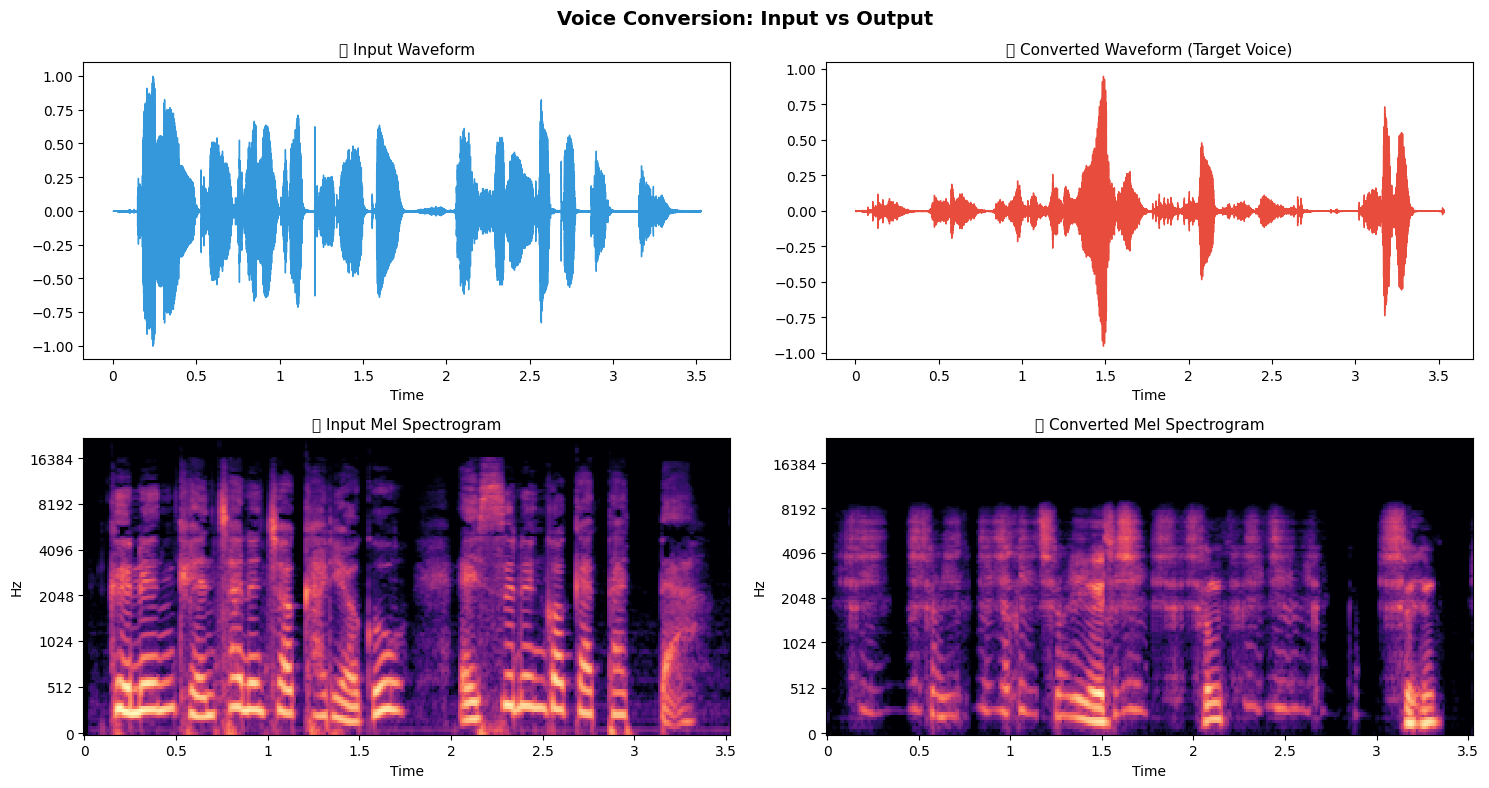


🎙️ 원본 음성:



🔊 변환된 음성 (타겟 목소리):



💾 결과 저장됨: /content/drive/MyDrive/RVC_MetaLearning/output/원본 음성_converted.wav
📥 파일을 다운로드하려면 아래 셀을 실행하세요:
   files.download('/content/drive/MyDrive/RVC_MetaLearning/output/원본 음성_converted.wav')


In [40]:
# =============================================================================
# [셀 17] 음성 변환 실행 & 결과 확인
# =============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display
from google.colab import files

DRIVE_ROOT = "/content/drive/MyDrive/RVC_MetaLearning"
OUTPUT_DIR = f"{DRIVE_ROOT}/output"

print("=" * 60)
print("🎤 Step 5-C: 음성 변환 실행")
print("=" * 60)

# ===== 옵션 1: Google Drive에서 파일 지정 =====
# 변환할 입력 WAV 파일 경로를 지정하세요
INPUT_WAV = ""  # 예: "/content/drive/MyDrive/test_voice.wav"

# ===== 옵션 2: 파일 업로드 =====
if not INPUT_WAV or not os.path.exists(INPUT_WAV):
    print("📤 변환할 WAV 파일을 업로드하세요:")
    uploaded = files.upload()
    if uploaded:
        INPUT_WAV = list(uploaded.keys())[0]
        # /content/에 저장
        INPUT_WAV = f"/content/{INPUT_WAV}"
        print(f"  ✅ 업로드됨: {INPUT_WAV}")
    else:
        raise FileNotFoundError("변환할 파일이 없습니다!")

# ===== 변환 실행 =====
print(f"\n🔄 음성 변환 중...")
output_path, audio_out = converter.convert(
    input_path=INPUT_WAV,
    f0_up_key=0,          # 피치 변환 (0=유지, +12=한 옥타브 올림)
    index_ratio=0.75,     # Faiss 검색 비율 (0.6~0.8 권장)
)

# ===== 결과 비교 시각화 =====
audio_in, sr_in = sf.read(INPUT_WAV)
if len(audio_in.shape) > 1:
    audio_in = audio_in.mean(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# 입력 파형
librosa.display.waveshow(audio_in, sr=sr_in, ax=axes[0, 0], color='#3498DB')
axes[0, 0].set_title('🎙️ Input Waveform', fontsize=11)

# 출력 파형
librosa.display.waveshow(audio_out, sr=48000, ax=axes[0, 1], color='#E74C3C')
axes[0, 1].set_title('🔊 Converted Waveform (Target Voice)', fontsize=11)

# 입력 멜 스펙트로그램
S_in = librosa.feature.melspectrogram(y=audio_in, sr=sr_in, n_mels=128)
S_in_dB = librosa.power_to_db(S_in, ref=np.max)
librosa.display.specshow(S_in_dB, sr=sr_in, ax=axes[1, 0],
                          x_axis='time', y_axis='mel', cmap='magma')
axes[1, 0].set_title('🎙️ Input Mel Spectrogram', fontsize=11)

# 출력 멜 스펙트로그램
S_out = librosa.feature.melspectrogram(y=audio_out, sr=48000, n_mels=128)
S_out_dB = librosa.power_to_db(S_out, ref=np.max)
librosa.display.specshow(S_out_dB, sr=48000, ax=axes[1, 1],
                          x_axis='time', y_axis='mel', cmap='magma')
axes[1, 1].set_title('🔊 Converted Mel Spectrogram', fontsize=11)

plt.suptitle('Voice Conversion: Input vs Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== 오디오 재생 =====
print("\n🎙️ 원본 음성:")
display(Audio(audio_in, rate=sr_in))

print("\n🔊 변환된 음성 (타겟 목소리):")
display(Audio(audio_out, rate=48000))

# ===== 다운로드 =====
print(f"\n💾 결과 저장됨: {output_path}")
print("📥 파일을 다운로드하려면 아래 셀을 실행하세요:")
print(f"   files.download('{output_path}')")


In [41]:
# =============================================================================
# [셀 18] 배치 변환 & 다운로드 (선택)
# =============================================================================
import os
import soundfile as sf
from tqdm import tqdm
from google.colab import files
import zipfile

DRIVE_ROOT = "/content/drive/MyDrive/RVC_MetaLearning"
OUTPUT_DIR = f"{DRIVE_ROOT}/output"

print("=" * 60)
print("📦 배치 음성 변환")
print("=" * 60)

# ===== 배치 변환할 폴더 지정 =====
BATCH_INPUT_DIR = ""  # 예: "/content/drive/MyDrive/input_voices/"

if BATCH_INPUT_DIR and os.path.isdir(BATCH_INPUT_DIR):
    wav_files = sorted([
        f for f in os.listdir(BATCH_INPUT_DIR) if f.lower().endswith(".wav")
    ])
    print(f"📂 변환할 파일: {len(wav_files)}개\n")

    results = []
    for fname in tqdm(wav_files, desc="배치 변환"):
        input_path = os.path.join(BATCH_INPUT_DIR, fname)
        output_name = f"{os.path.splitext(fname)[0]}_converted.wav"
        output_path = os.path.join(OUTPUT_DIR, output_name)

        try:
            converter.convert(
                input_path=input_path,
                output_path=output_path,
                f0_up_key=0,
                index_ratio=0.75,
            )
            results.append((fname, "✅ 성공"))
        except Exception as e:
            results.append((fname, f"❌ 실패: {e}"))

    print(f"\n{'='*60}")
    print("📊 배치 변환 결과:")
    for fname, status in results:
        print(f"  {status} {fname}")

    # ZIP 압축 & 다운로드
    zip_path = f"{OUTPUT_DIR}/converted_voices.zip"
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in os.listdir(OUTPUT_DIR):
            if f.endswith("_converted.wav"):
                zf.write(os.path.join(OUTPUT_DIR, f), f)
    print(f"\n💾 ZIP 저장: {zip_path}")
    print("📥 다운로드하려면: files.download(f'{zip_path}')")
else:
    print("⚠️ BATCH_INPUT_DIR를 설정하세요.")
    print("   예: BATCH_INPUT_DIR = '/content/drive/MyDrive/input_voices/'")
    print("\n   또는 단일 파일 변환은 이전 셀(셀 17)을 사용하세요.")


📦 배치 음성 변환
⚠️ BATCH_INPUT_DIR를 설정하세요.
   예: BATCH_INPUT_DIR = '/content/drive/MyDrive/input_voices/'

   또는 단일 파일 변환은 이전 셀(셀 17)을 사용하세요.
